# Figure 4B, S4B, S5G, S5H — the fifteen independent components

Decomposes the significant effect-size matrix into 15 independent components,
takes the outlying knockouts and outlying affected genes of each one, and asks
how much the components overlap in the knockouts and in the genes they pick out.

## Setup

In [1]:
library(pheatmap)
library(ica)
library(bayesbio)   # jaccardSets
library(repr)

DATA_DIR    <- "/home/eraslab1/Projects/E3Ligase/analysisSingle/TextFiles"
N_FACTORS   <- 15
RANDOM_SEED <- 1

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x; only what this notebook uses
# is loaded here. save_pheatmap_pdf is inlined from Utilities.R.

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

ANNO_COLORS <- list(
    GeneGroup = c(G0 = "#A6CEE3", G1 = "#1F78B4", G2  = "#B2DF8A", G3 = "#33A02C",
                  G4 = "#FB9A99", G5 = "#FDBF6F", G6  = "#FF7F00", G7 = "#CAB2D6",
                  G8 = "#6A3D9A", G9 = "#FFFF99", G10 = "#B5651D"),
    GuideGroup = c(M1 = "#aa40fc", M2 = "#1f77b4", M3 = "#ff7f0e",
                   M4 = "#8c564b", M5 = "#d62728", M6 = "#279e68"))

## Effect sizes and modules

The coefficient matrix is transposed so that knockouts are columns; row names
are guide identifiers, of which only the gene name part is kept. Both module
tables carry an old and a new naming; the new names (`M1`–`M6`) are the ones
used throughout.

In [2]:
selCoefs <- t(read.csv(file.path(DATA_DIR, "SignificantCoefMatrix.csv"), row.names = 1))
KOGenes  <- sapply(colnames(selCoefs), function(x) strsplit(x, "_")[[1]][2])
colnames(selCoefs) <- KOGenes

guideModulesN <- read.csv(file.path(DATA_DIR, "ME_GuideModules_leiden_6_Modules.csv"),
                          row.names = 1)
rownames(guideModulesN)       <- guideModulesN$GuideName
guideModulesN$GuideGroup      <- guideModulesN$NewGuideGroup   # modules are named M1..M6
guideModulesN[c("GuideName", "NewGuideGroup", "GuideColor")] <- NULL

geneModulesN <- read.csv(file.path(DATA_DIR, "ME_GeneModules_leiden_11_Modules.csv"),
                         row.names = 1)
rownames(geneModulesN)      <- geneModulesN$GeneName
geneModulesN$GeneGroup      <- factor(geneModulesN$GeneGroup)
geneModulesN[c("GeneName", "NewGeneGroup", "GeneColor")] <- NULL

# Both frames now hold a single module column; the colours come from ANNO_COLORS.

dim(selCoefs)

[1] 1041  329

## Independent components

:::{note}
`icaimax` is stochastic and the original notebook did not seed it. A seed is
set here so the decomposition is reproducible. With this seed the outlying
knockouts of all fifteen factors are identical to the published factor
definitions, factor numbering included.
:::

In [3]:
set.seed(RANDOM_SEED)
ica <- icaimax(selCoefs, nc = N_FACTORS, center = TRUE)

myH <- data.frame(t(ica$S))                       # factors x affected genes
myW <- data.frame(ica$M)                          # knockouts x factors
rownames(myW) <- KOGenes
colnames(myH) <- rownames(selCoefs)
rownames(myH) <- paste0("Factor ", 1:nrow(myH))
colnames(myW) <- paste0("Factor ", 1:ncol(myW))

## One heatmap per factor

A factor's outliers are the knockouts and the affected genes lying more than
one interquartile range beyond the quartiles of its loadings, in either
direction.

:::{warning}
These gene sets are supersets of the published ones — each published set is an
exact subset of the set recomputed here, so the panels below show more genes
than the corresponding published supplementary heatmaps. No IQR multiplier
reproduces the published sets, so the paper narrowed them by a step that is not
in this notebook. The panels further down do not depend on this: they read the
published factor definitions from file.
:::

In [4]:
outliers_up <- function(x) {
    q <- quantile(x)
    x[x > q[4] + (q[4] - q[2])]
}

outliers_down <- function(x) {
    q <- quantile(x)
    x[x < q[2] - (q[4] - q[2])]
}

plotFactorHeatmap <- function(coefsAll, sKOGenes, sEffectGenes, elem) {
    tempDF <- coefsAll[sEffectGenes, sKOGenes]
    tempDF[tempDF >  0.2] <-  0.2
    tempDF[tempDF < -0.2] <- -0.2

    options(repr.plot.width = 10, repr.plot.height = 16)
    km2 <- pheatmap(tempDF, main = paste0("Factor ", elem),
                    na_col = "grey",
                    annotation_row = geneModulesN[rownames(tempDF), , drop = FALSE],
                    annotation_col = guideModulesN[colnames(tempDF), , drop = FALSE],
                    annotation_colors = ANNO_COLORS,
                    clustering_method = "ward.D2",
                    clustering_distance_rows = "euclidean",
                    clustering_distance_cols = "euclidean",
                    colorRampPalette(c("blue", "white", "orange"))(100))

    save_pheatmap_pdf(km2, paste0("figures/Factor_", elem, ".pdf"), width = 10, height = 16)
}

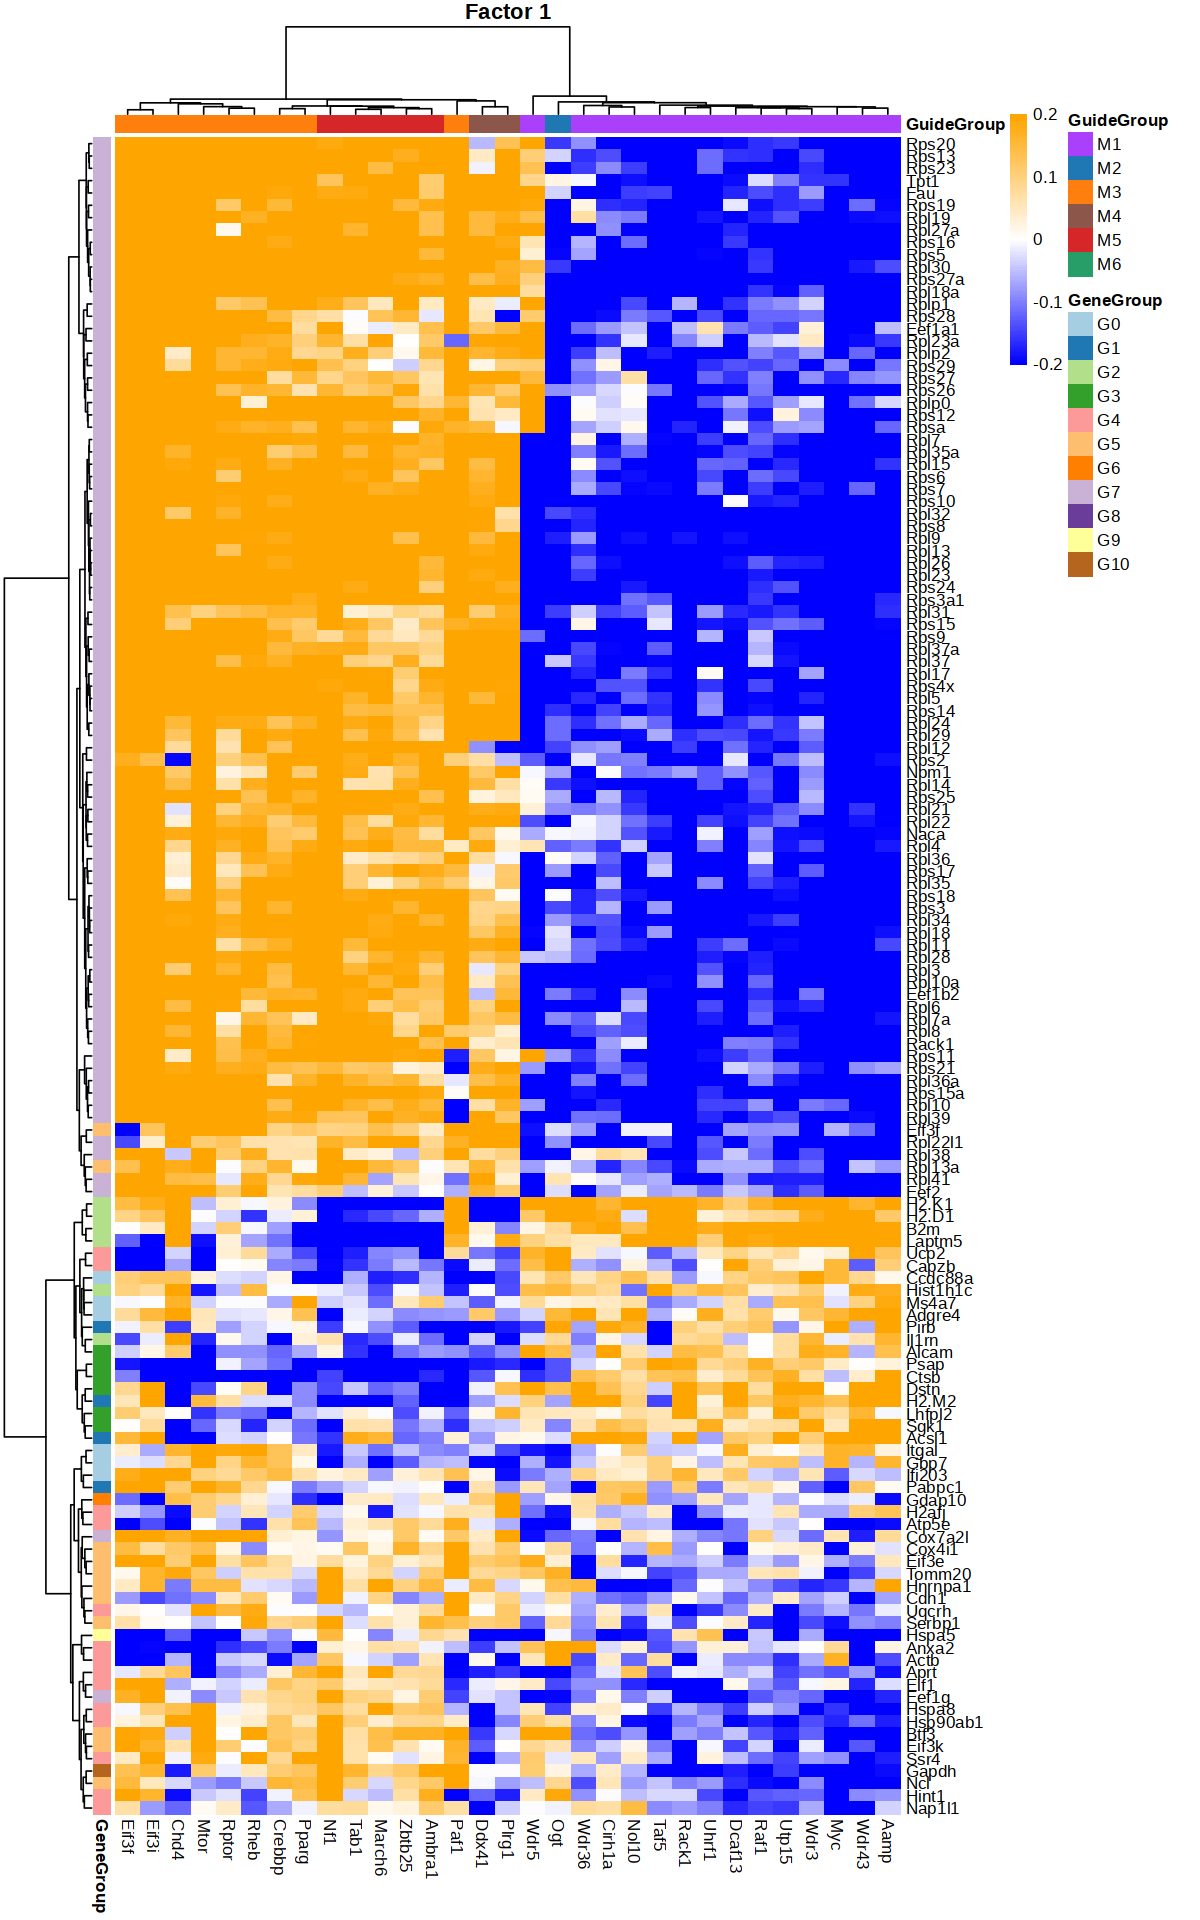

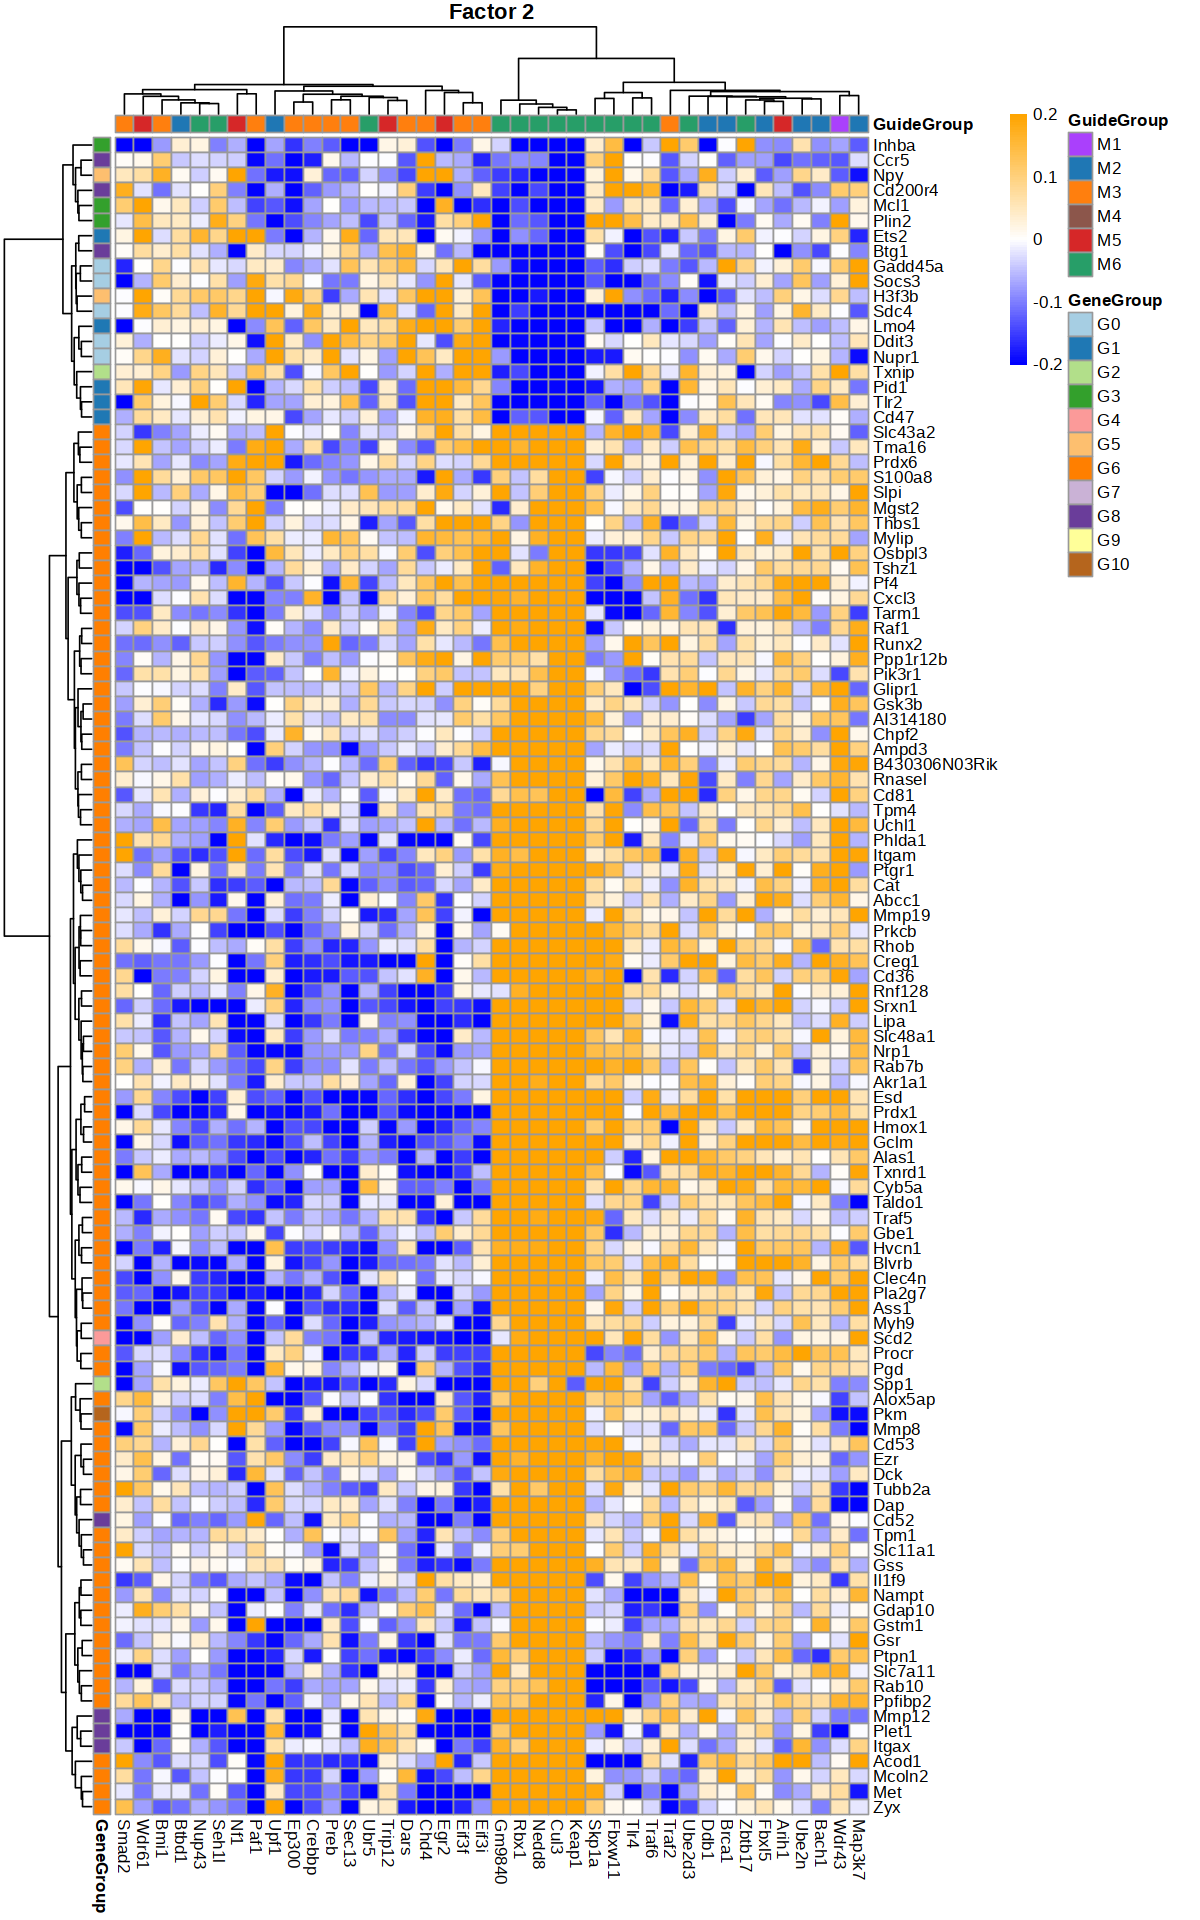

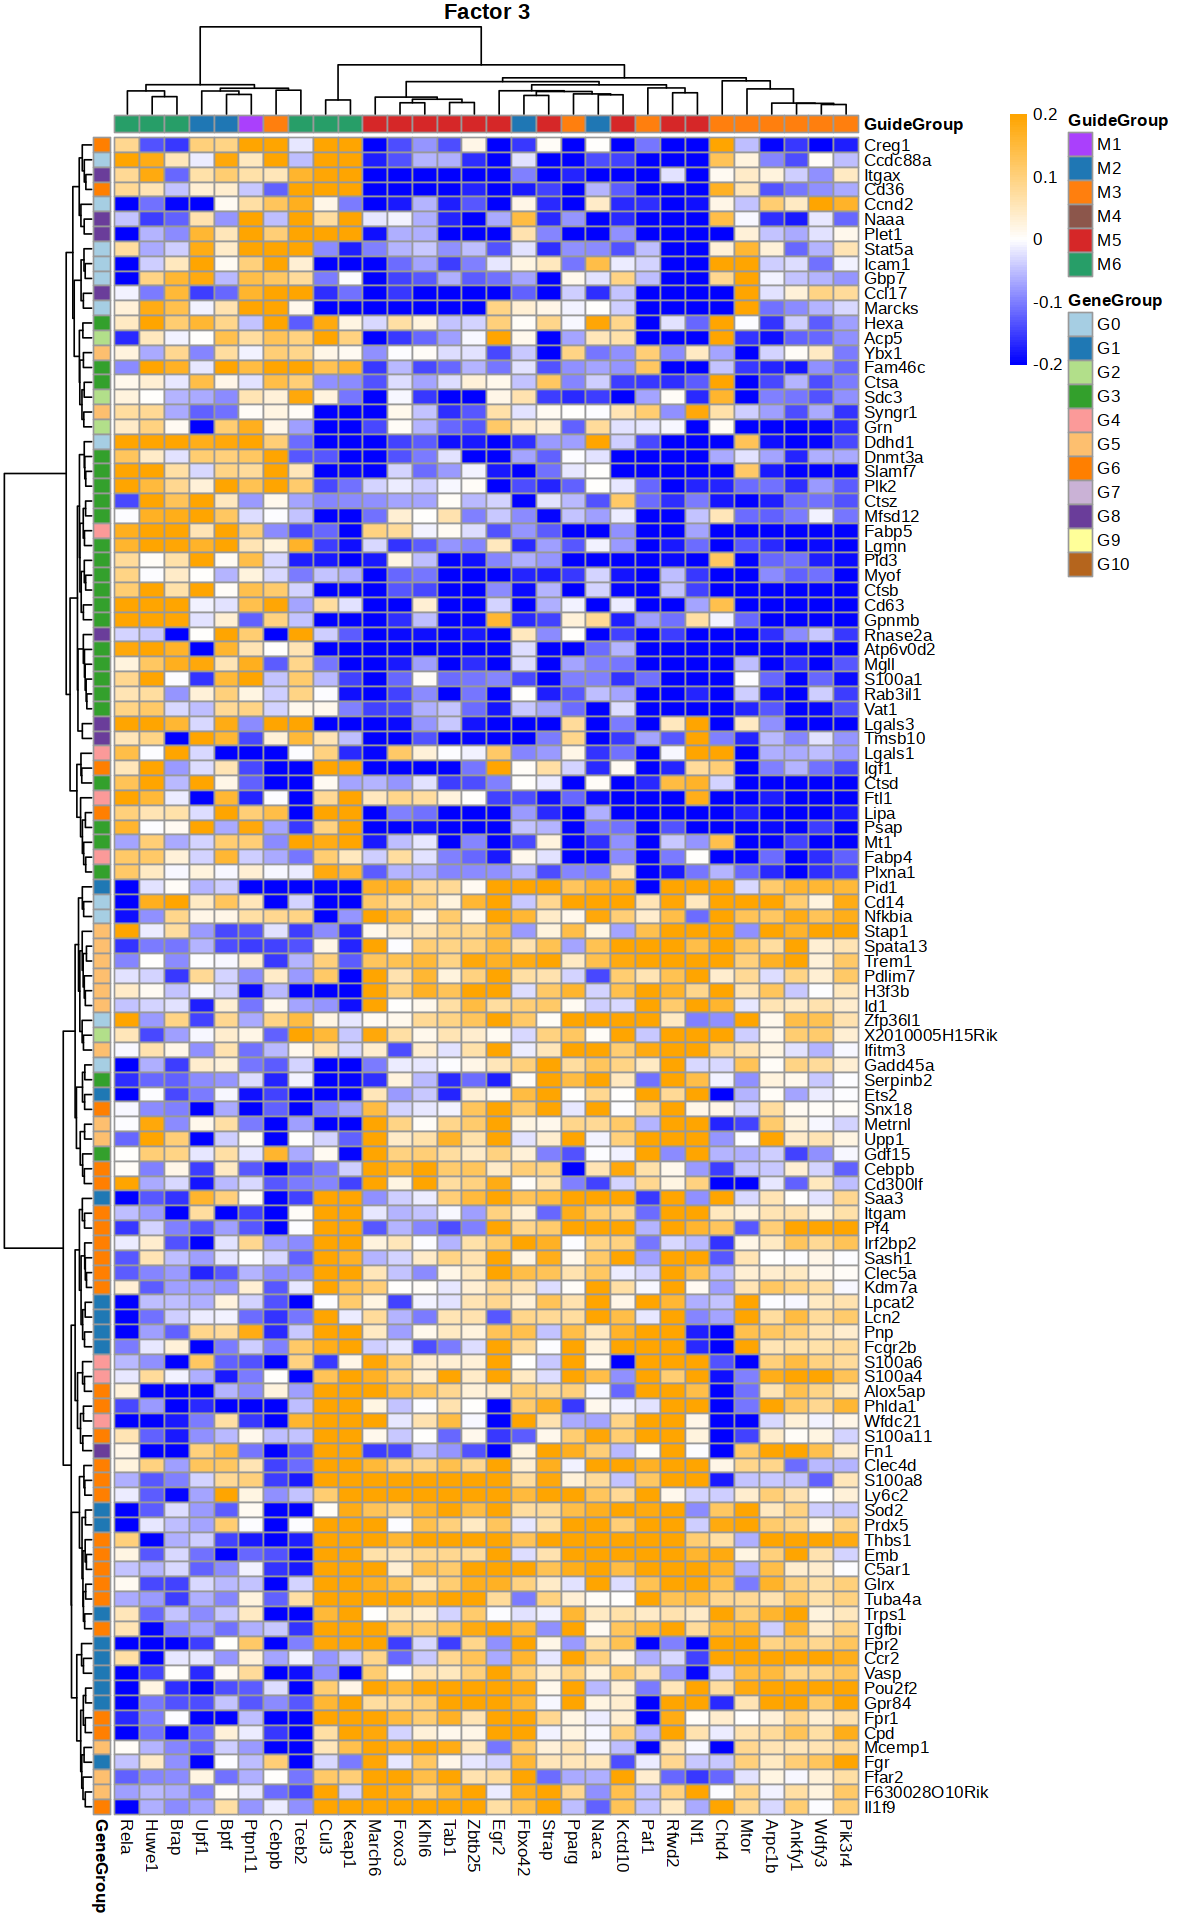

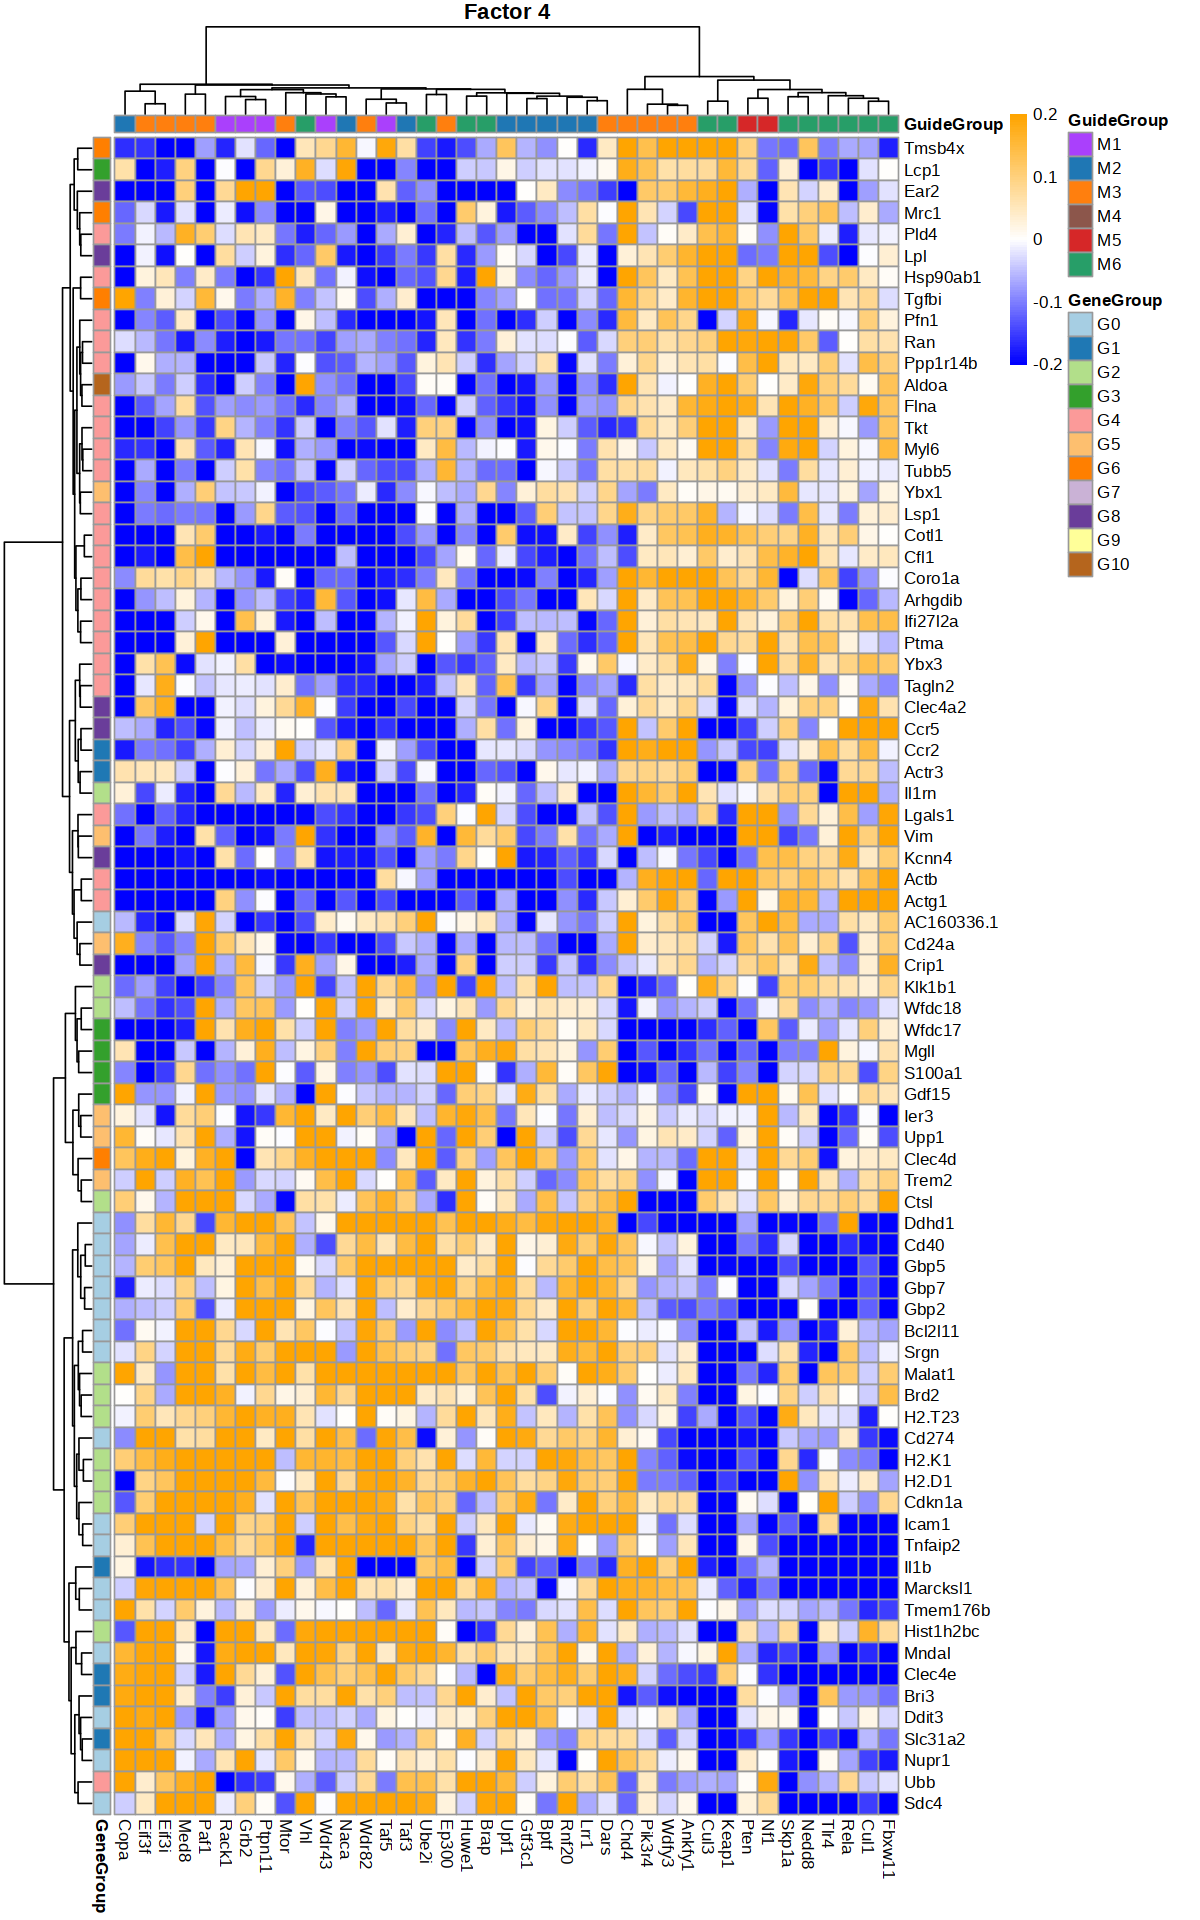

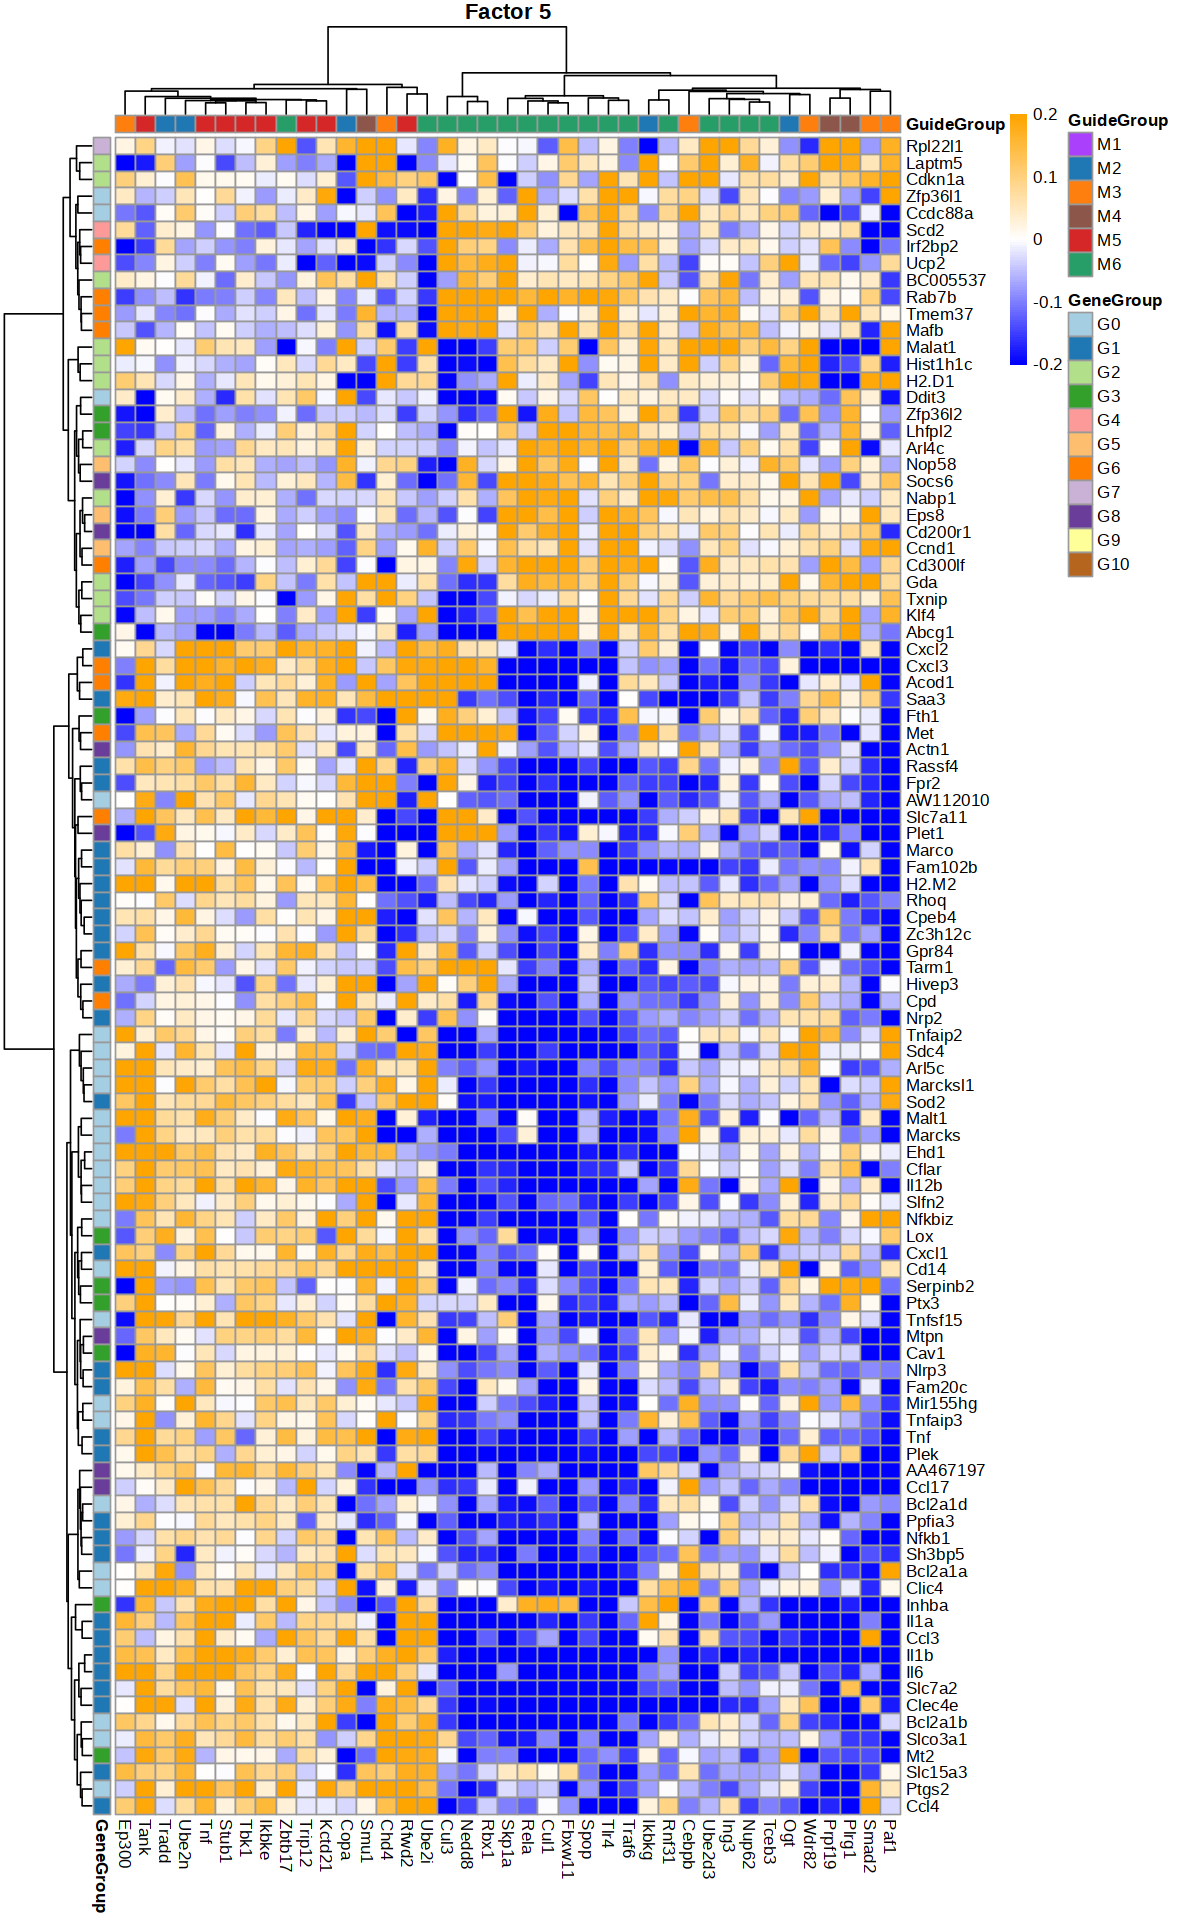

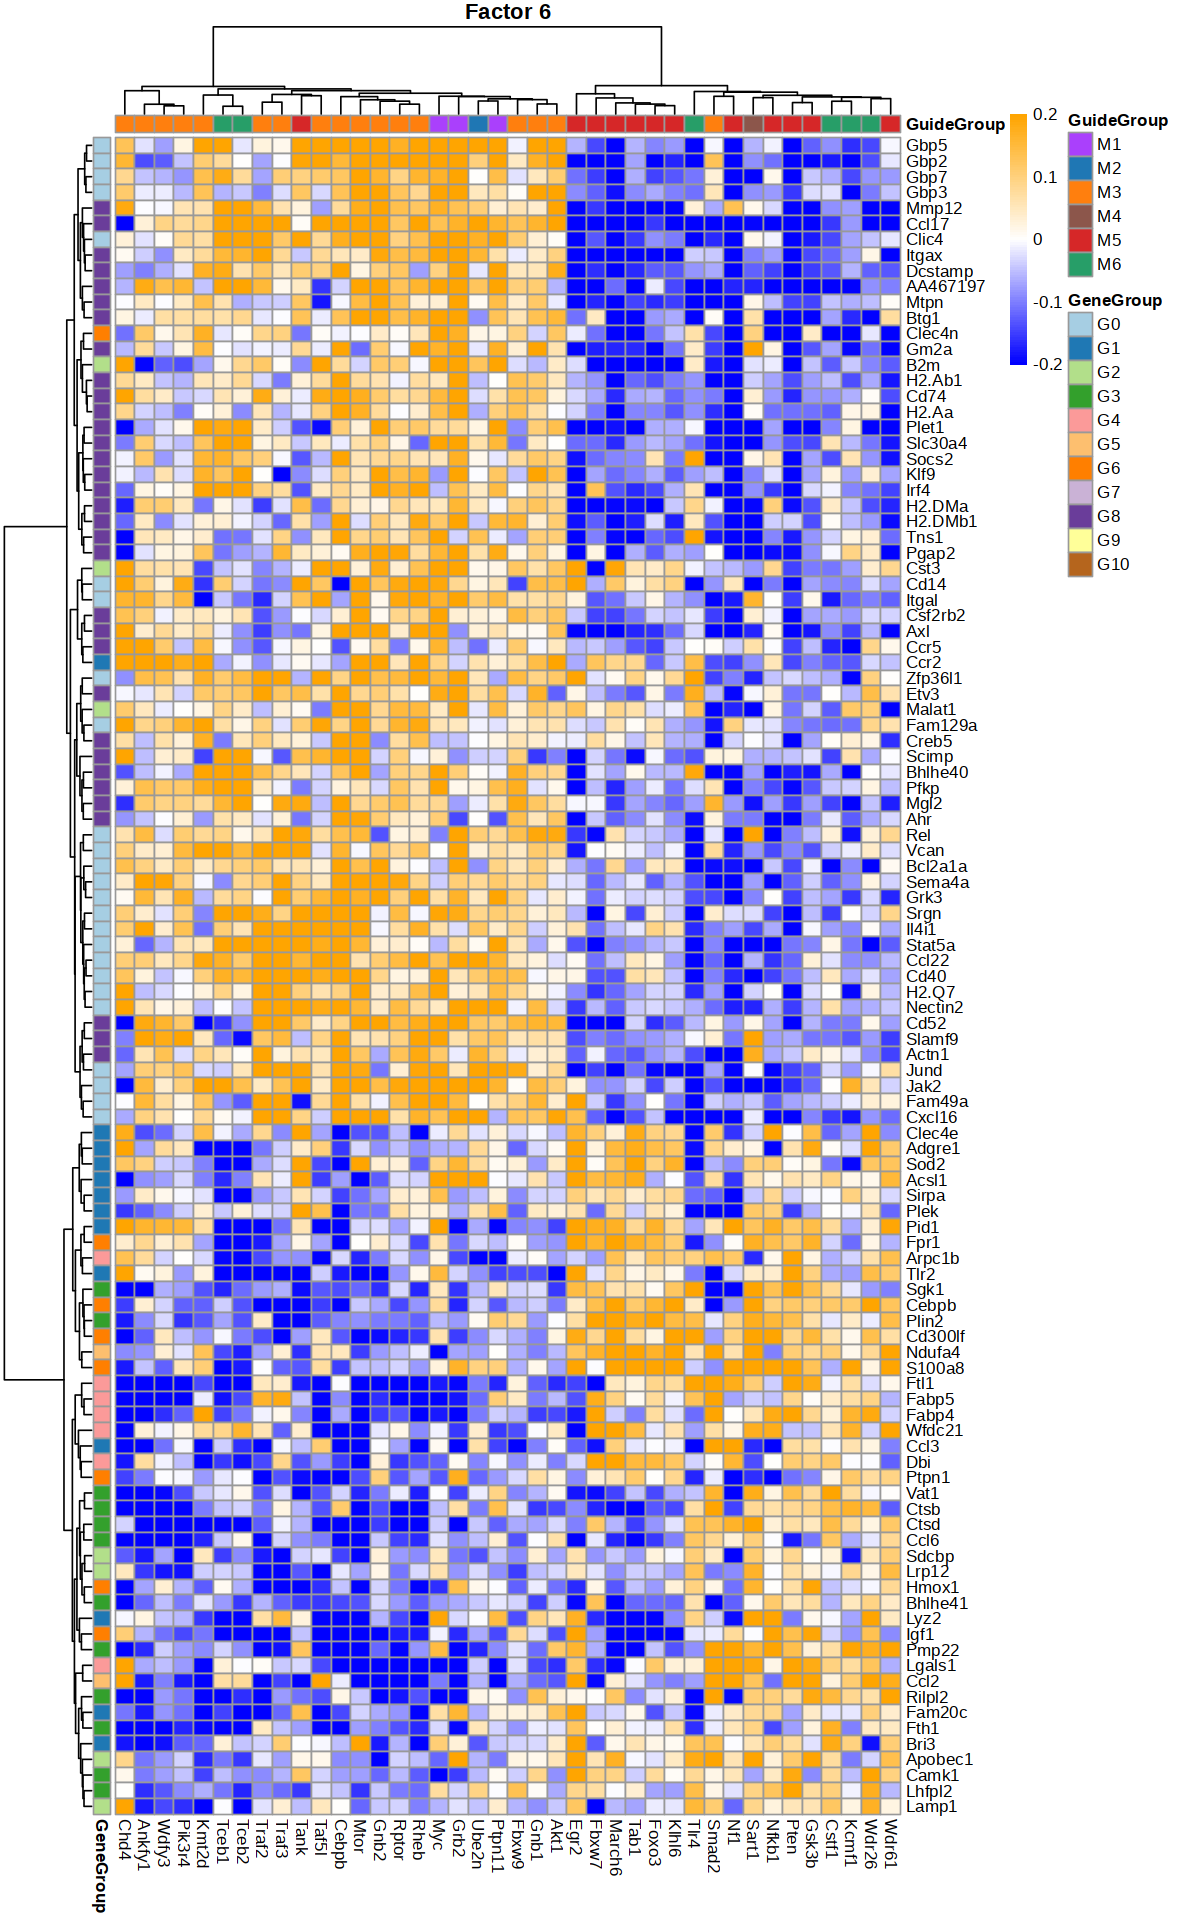

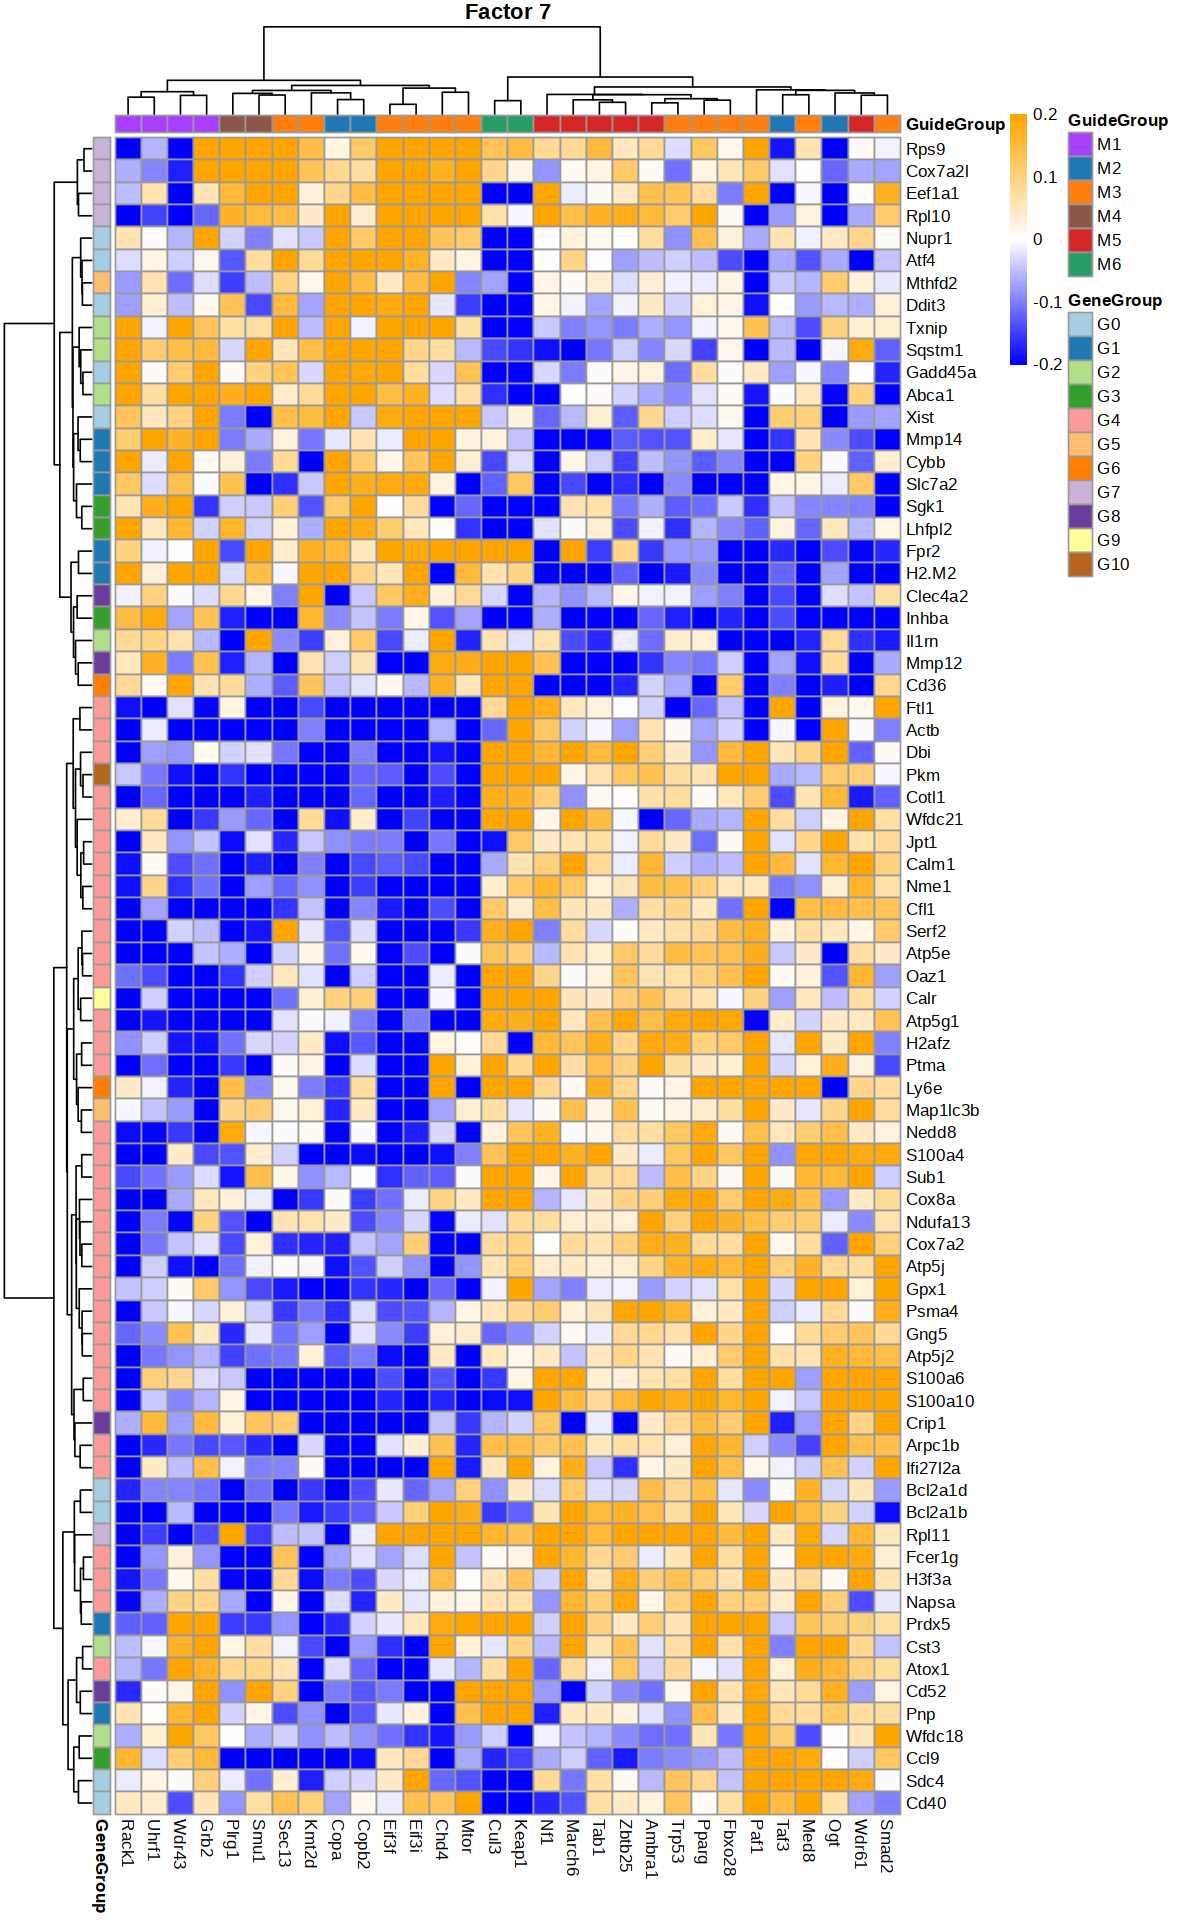

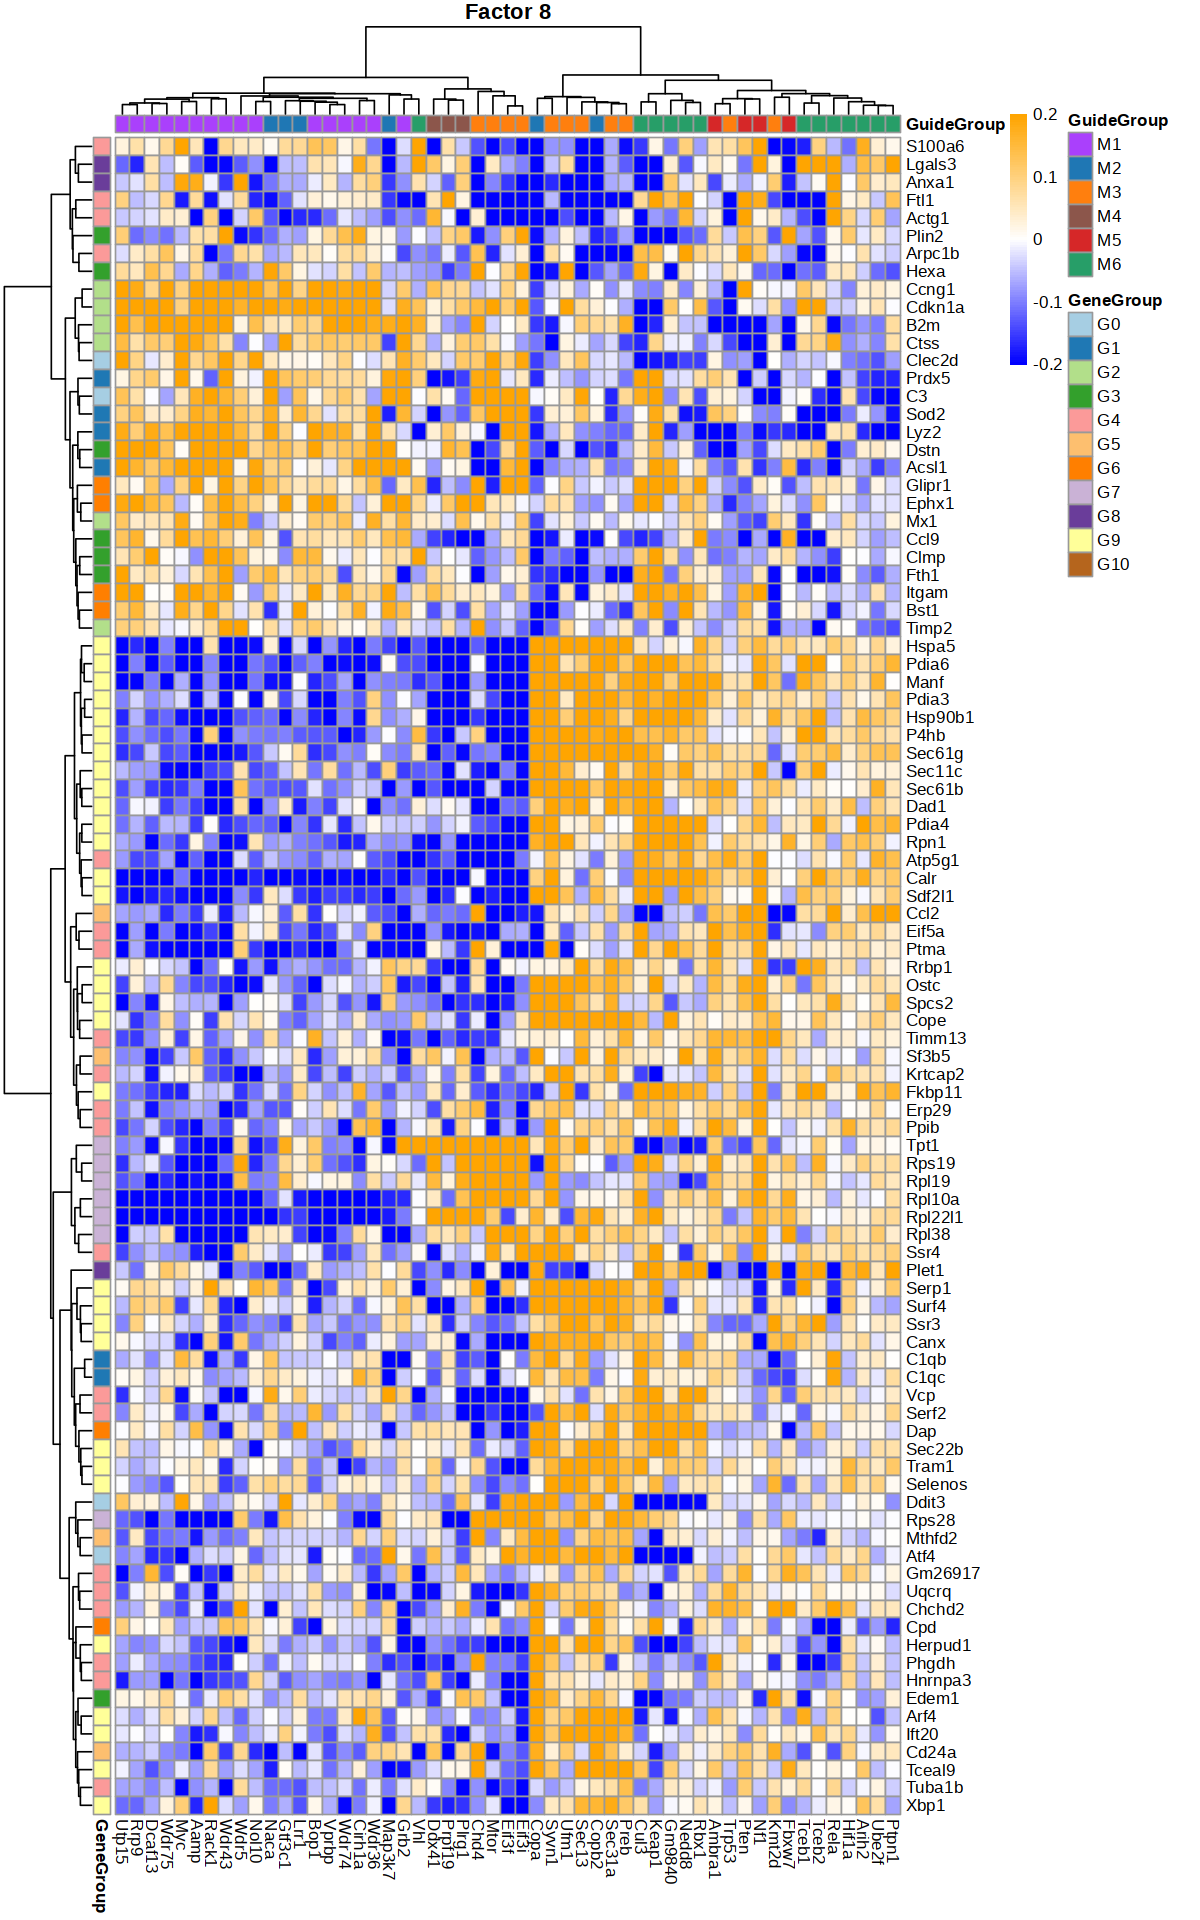

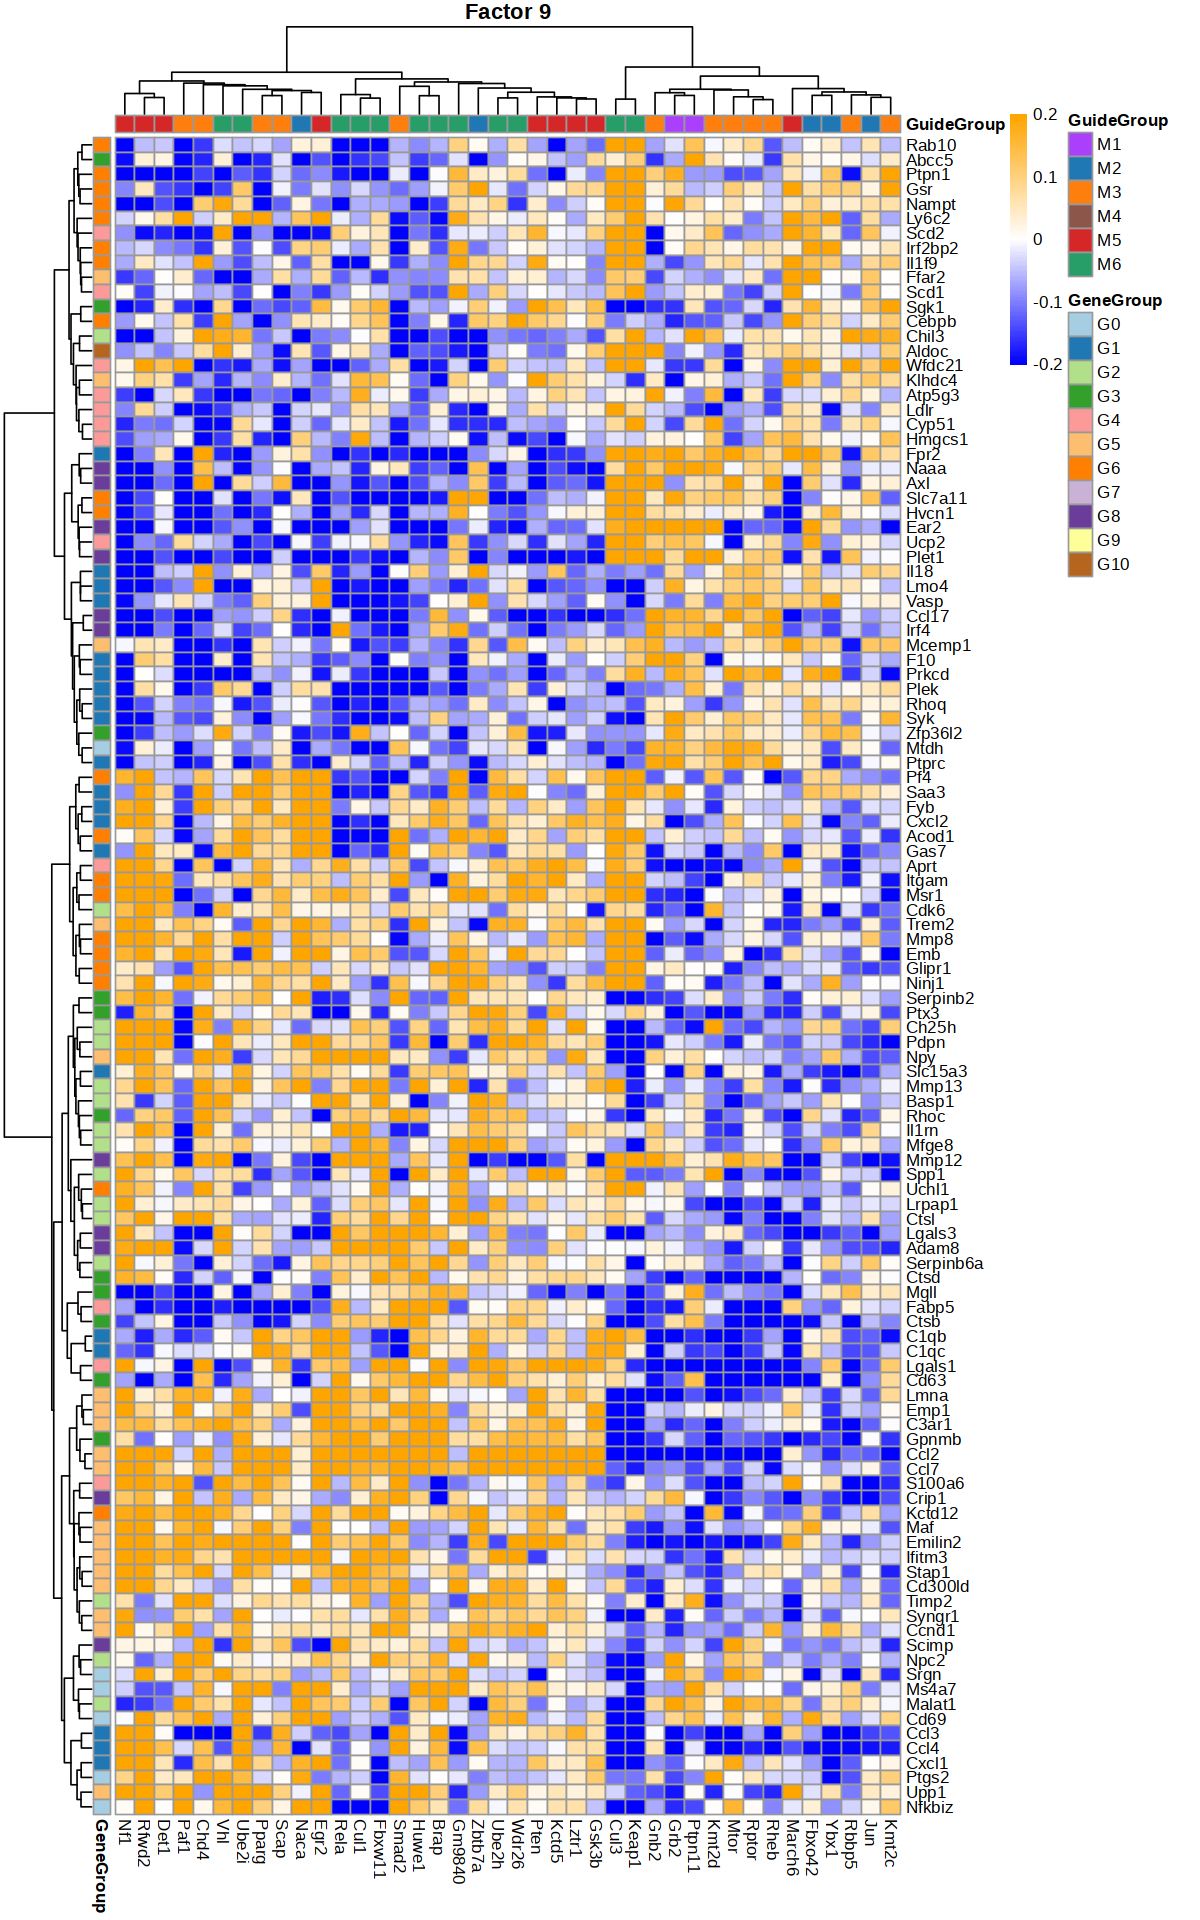

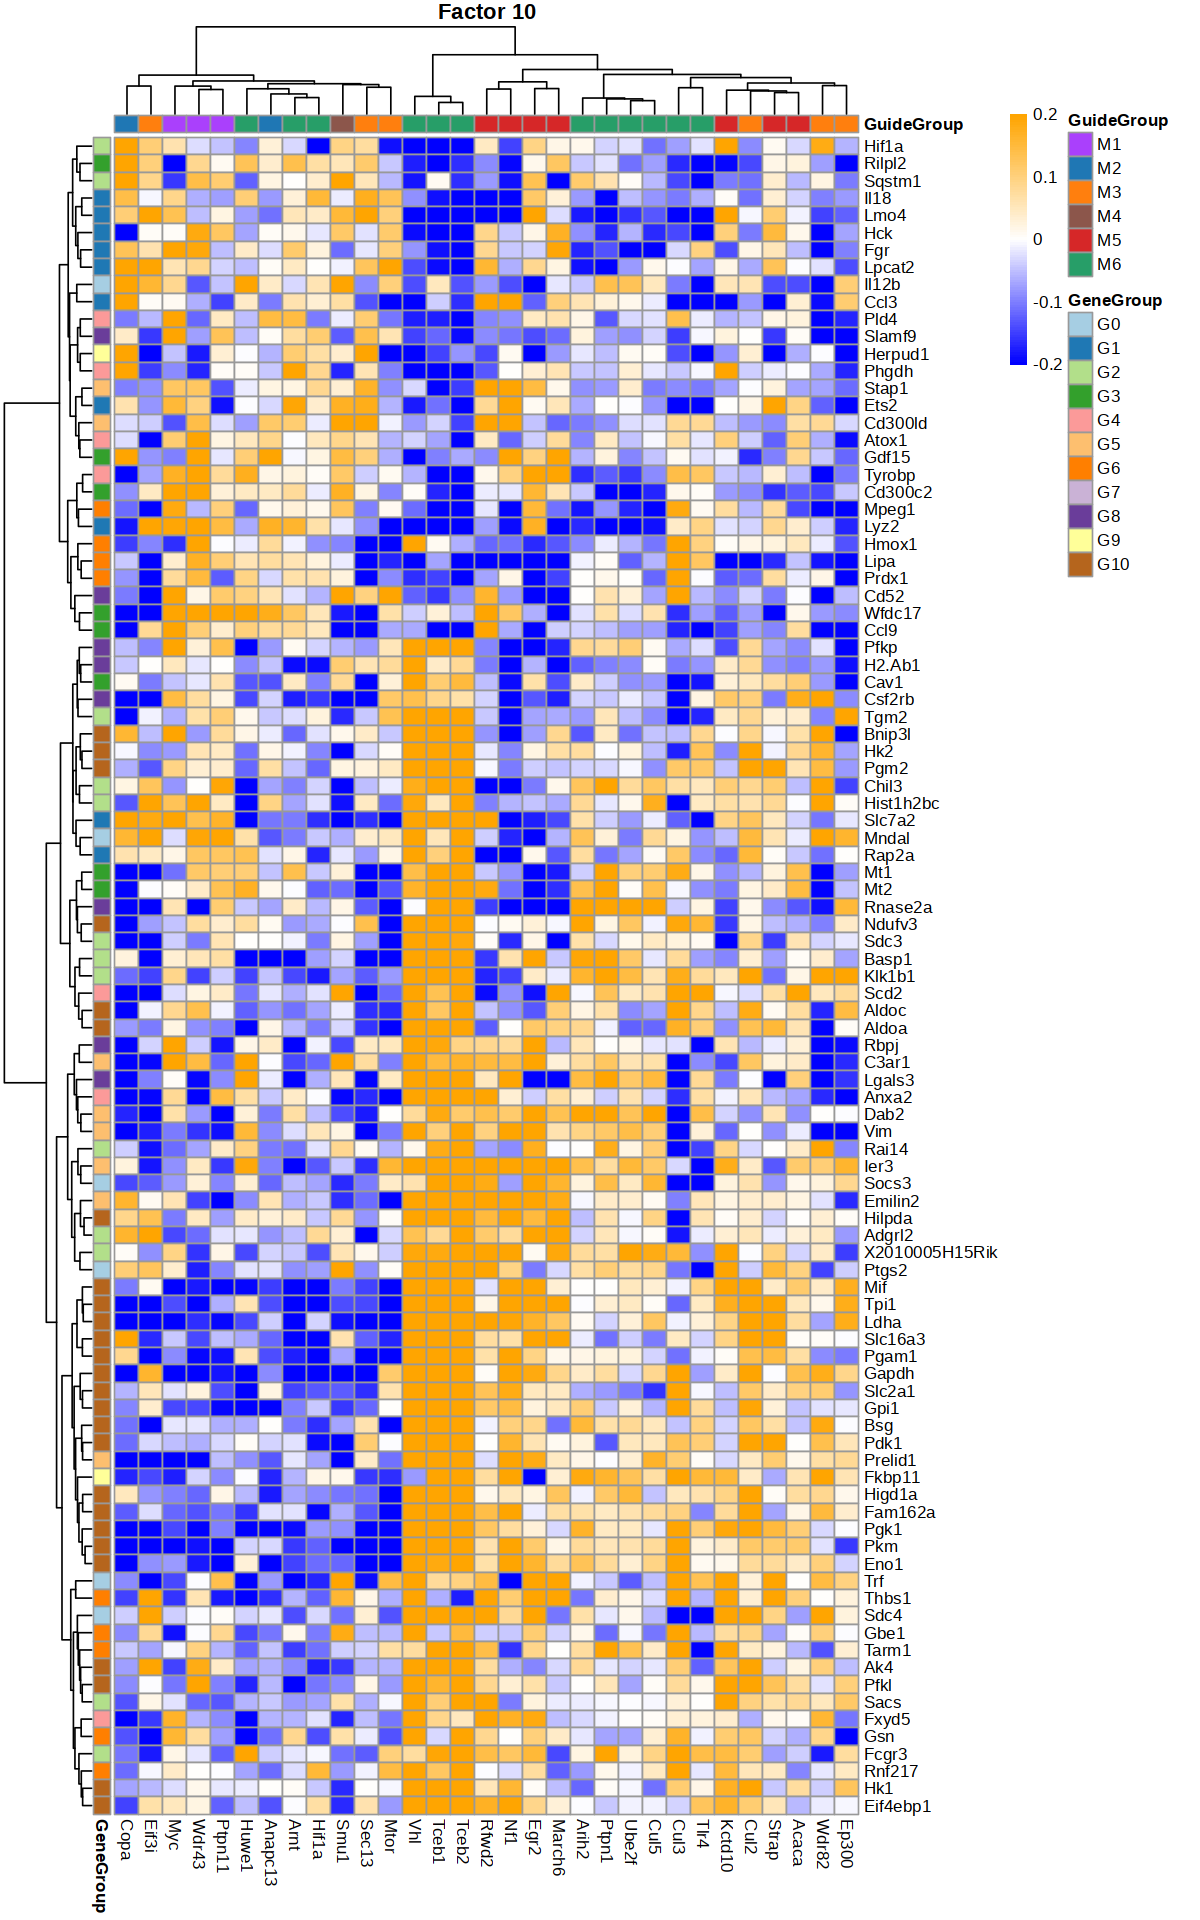

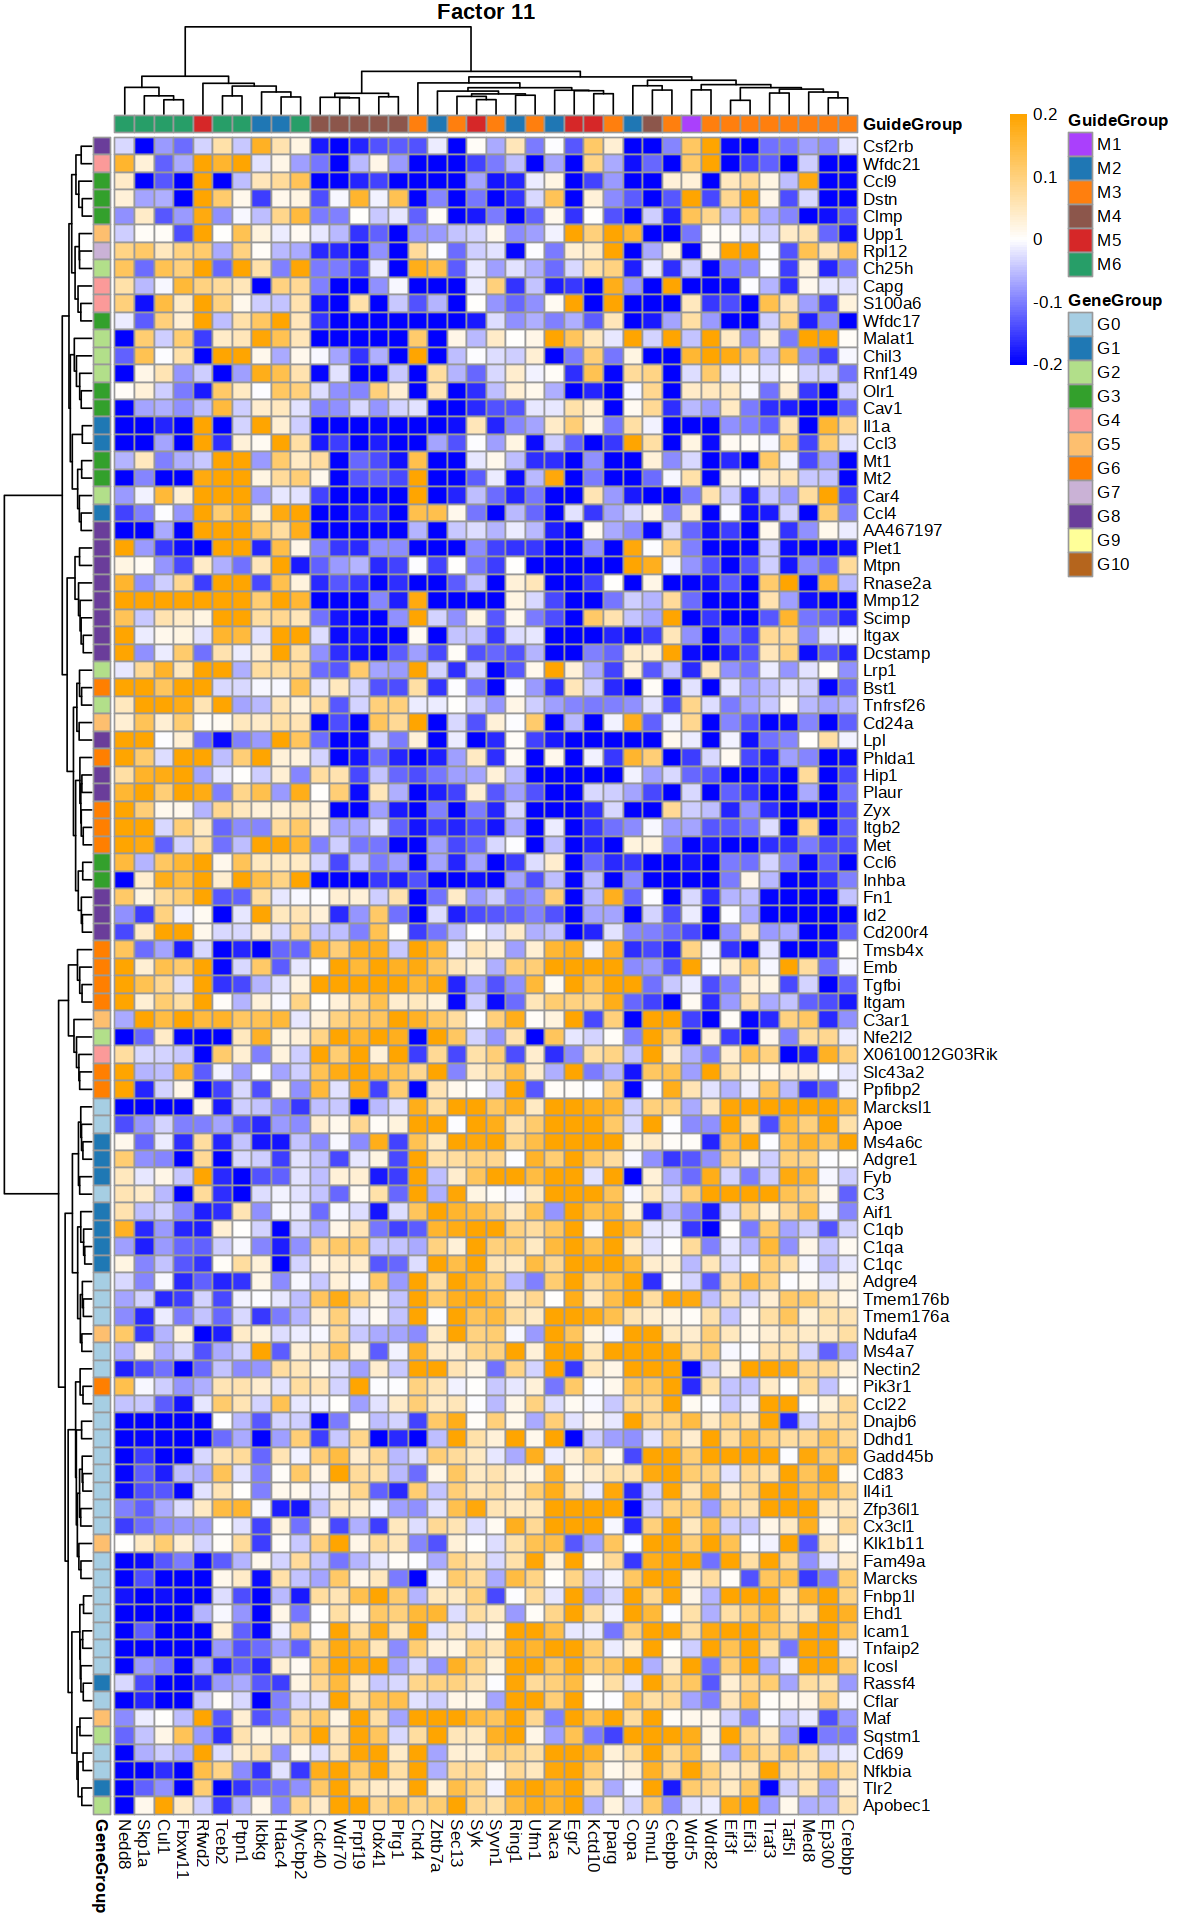

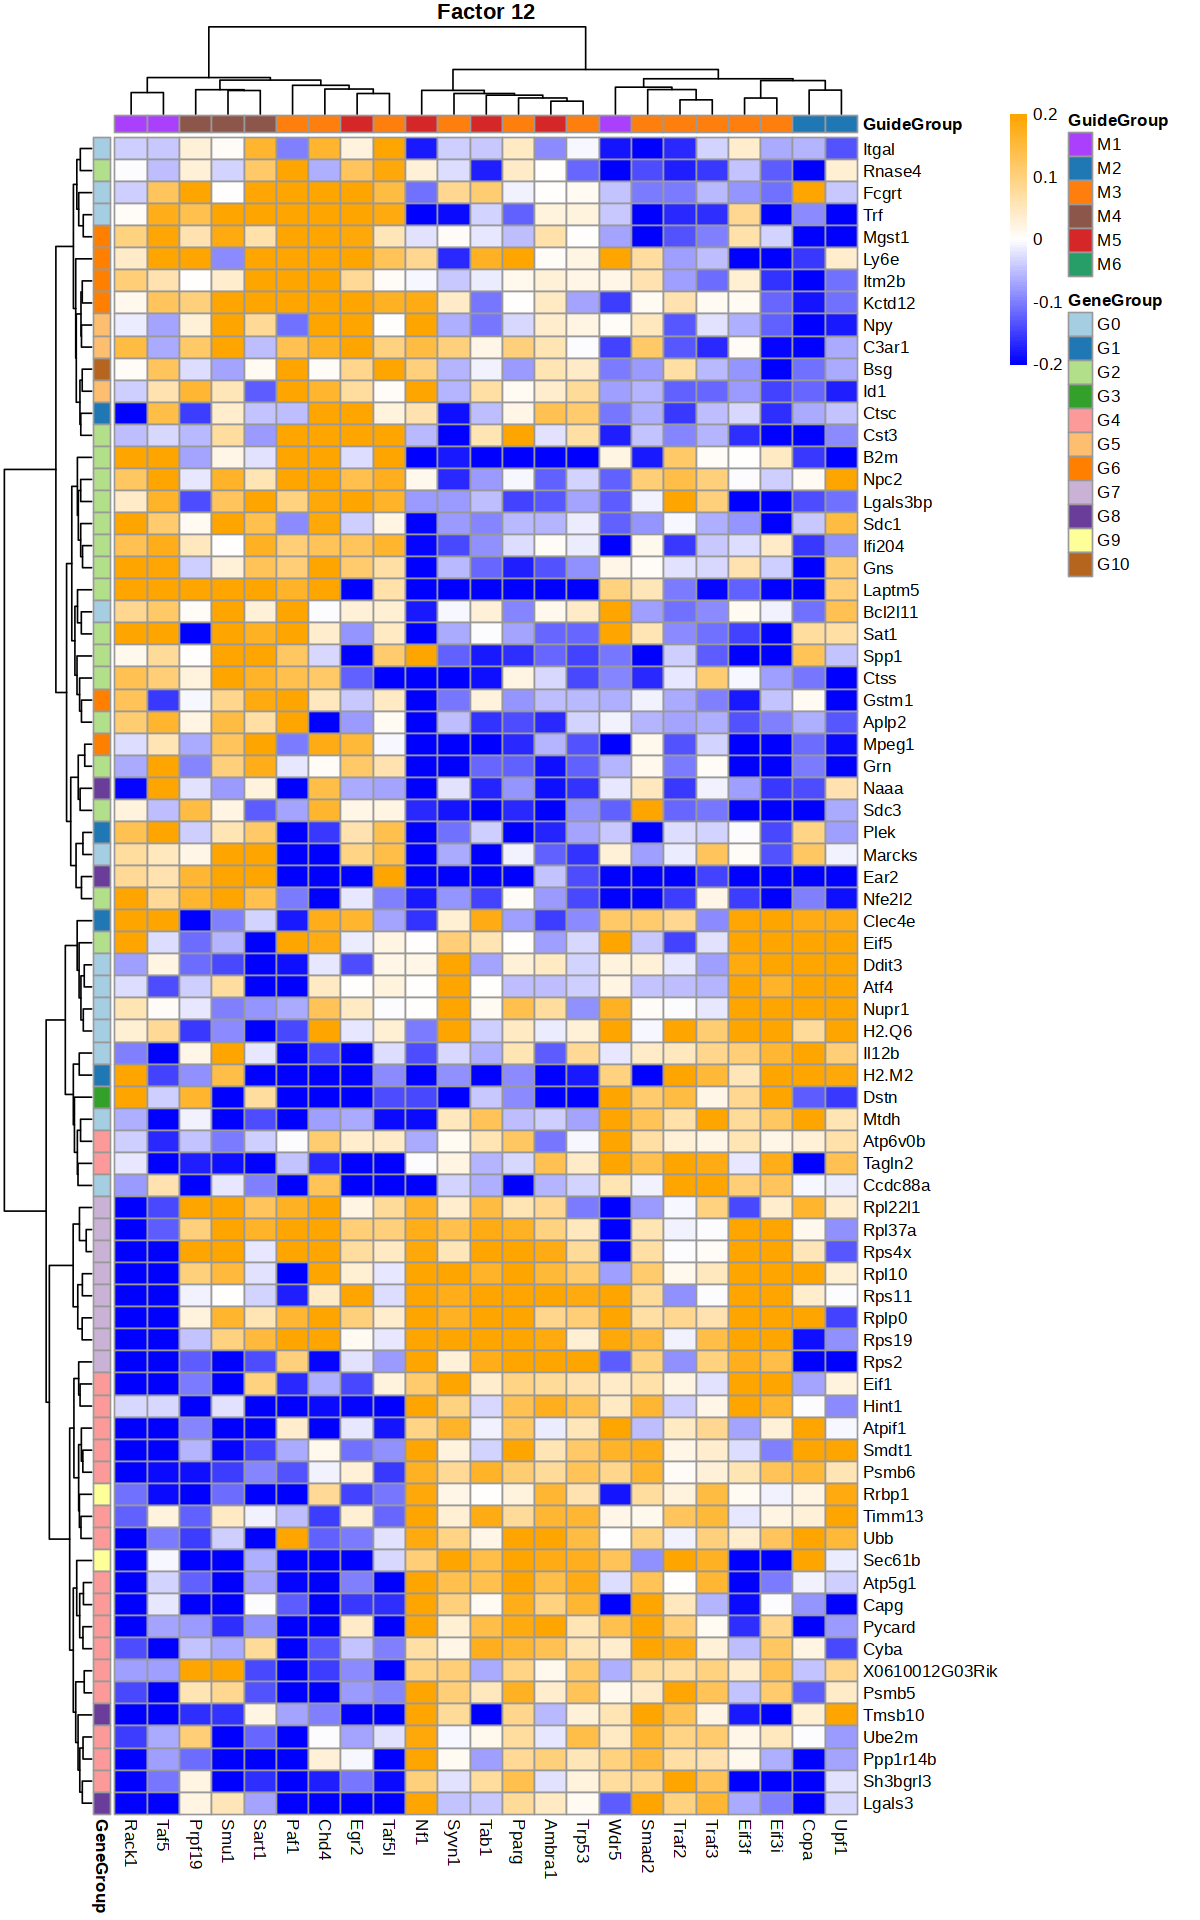

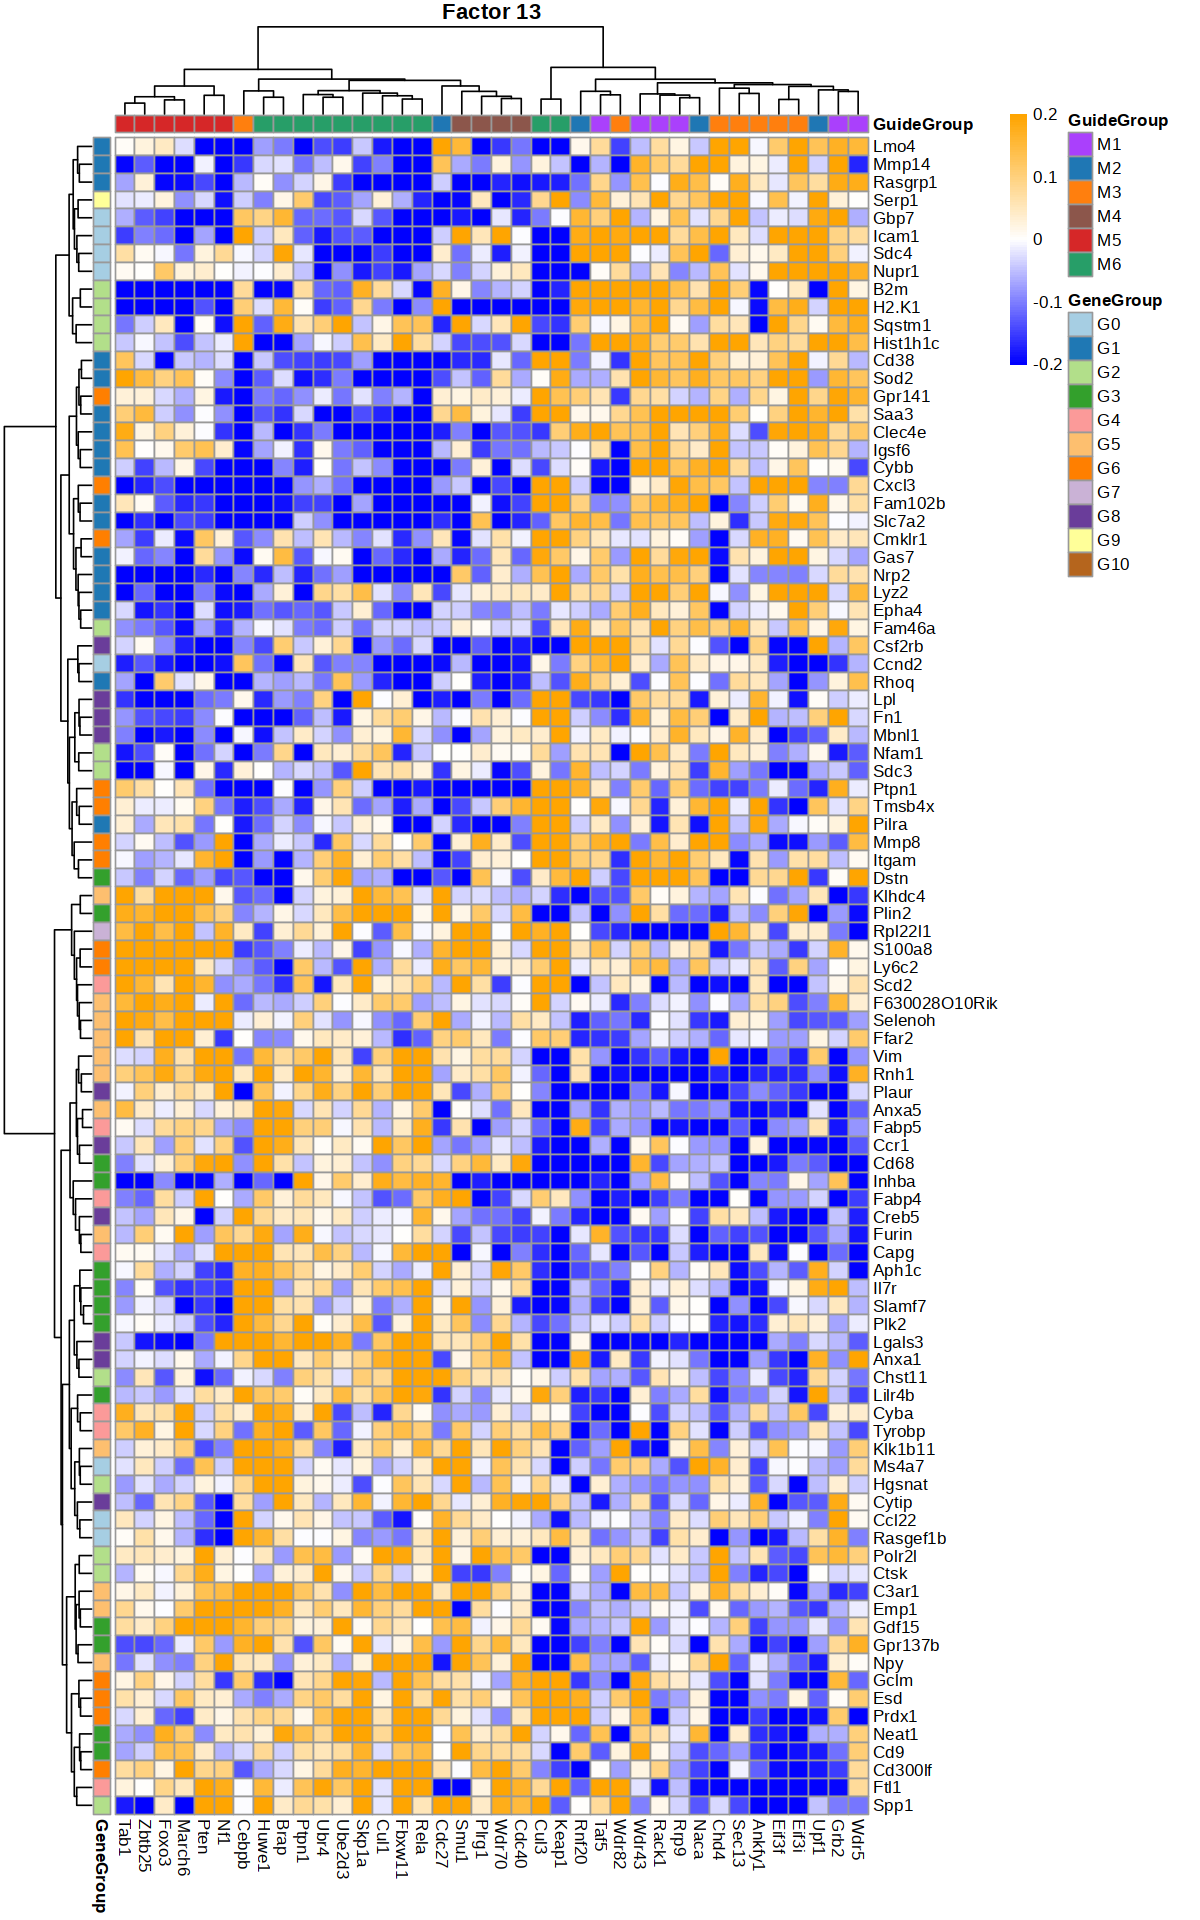

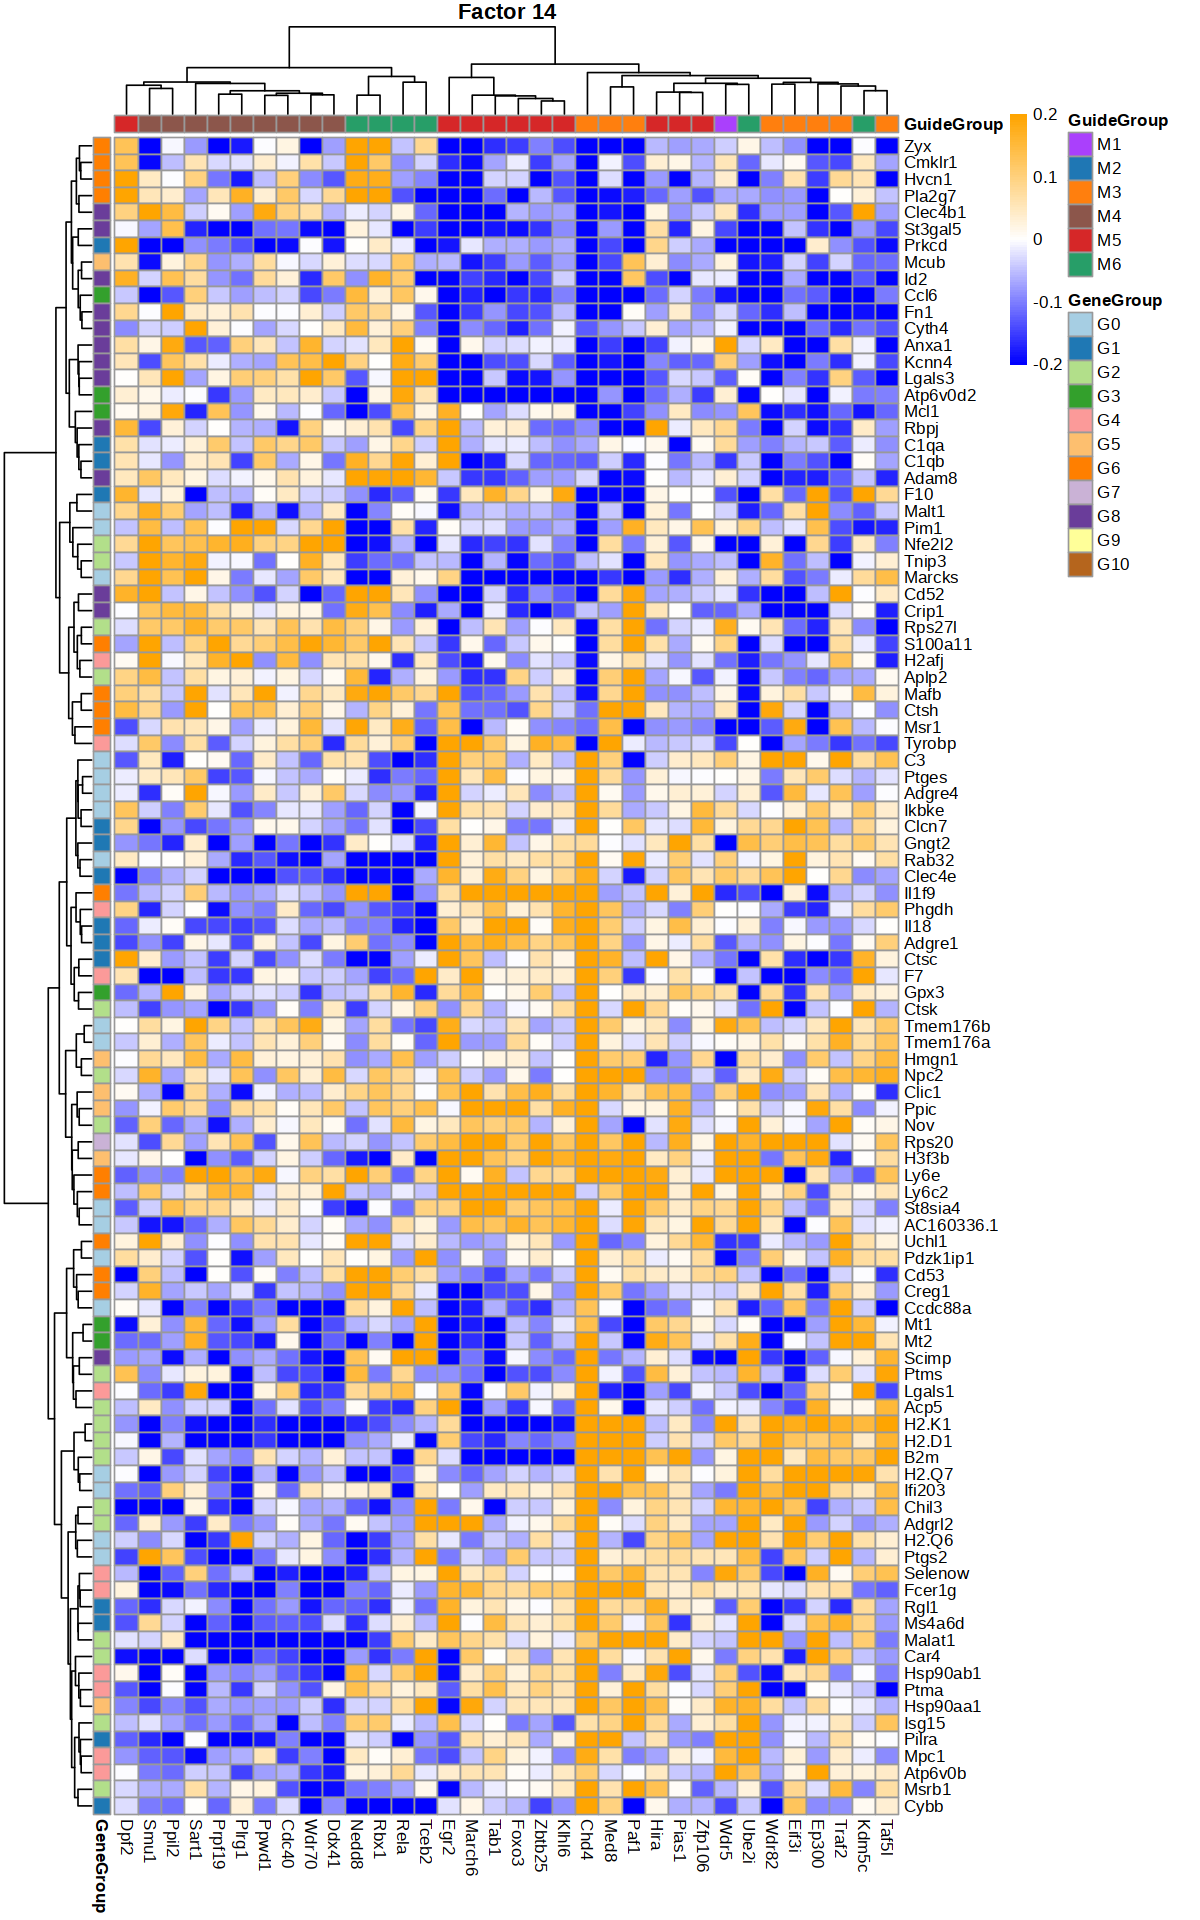

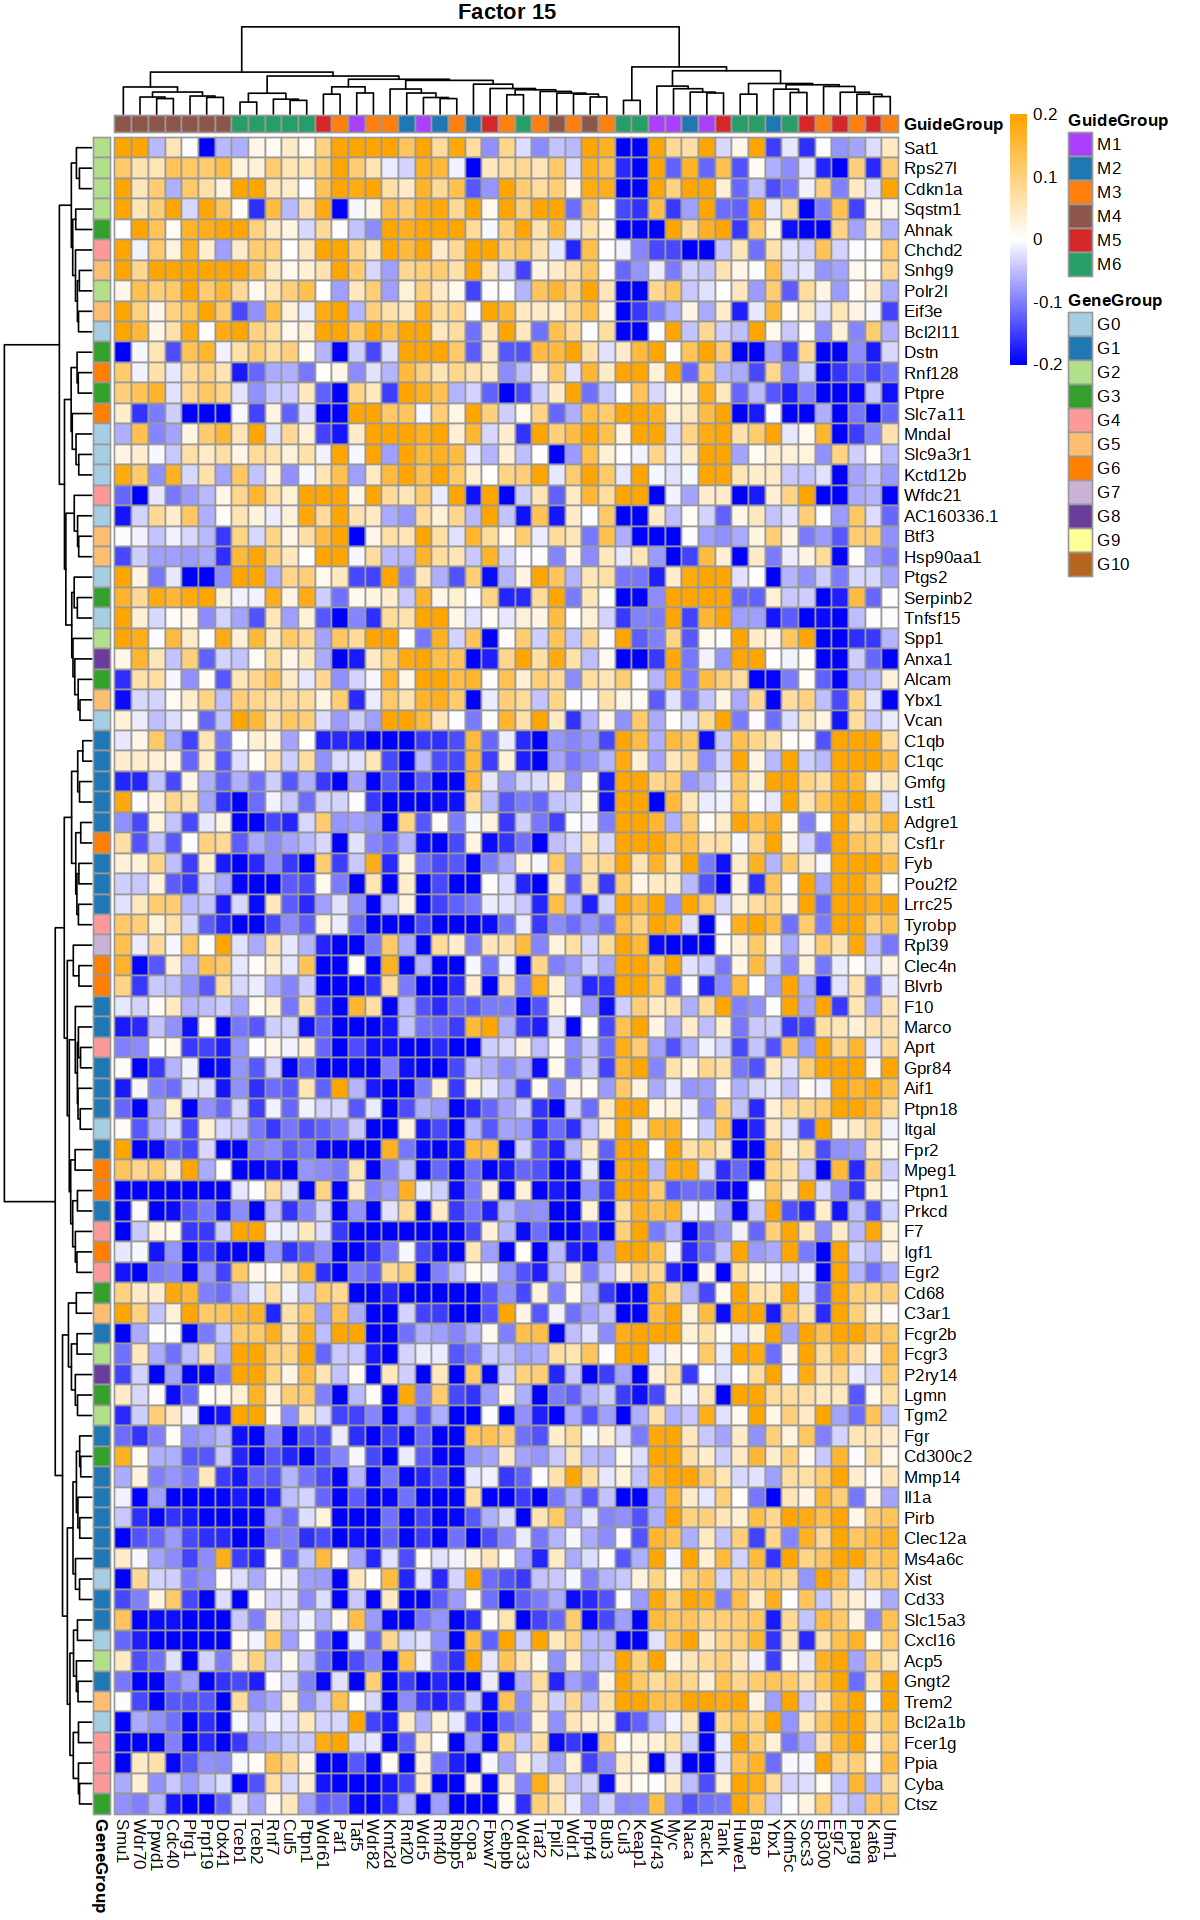

In [5]:
for (elem in 1:N_FACTORS) {
    koLoadings <- setNames(myW[, elem], rownames(myW))
    sKOGenes   <- c(names(outliers_up(koLoadings)), names(outliers_down(koLoadings)))

    geneLoadings <- setNames(unlist(myH[elem, ]), colnames(myH))
    sEffectGenes <- c(names(outliers_up(geneLoadings)), names(outliers_down(geneLoadings)))

    plotFactorHeatmap(selCoefs, sKOGenes, sEffectGenes, elem)
}

## Figure 4B — knockouts per factor

From here on the factor definitions come from the published file rather than
from the decomposition above, so these panels are fixed regardless of the seed.
Knockouts are ordered so that those loading on the earliest factors come first.

In [6]:
myICAFactors <- read.csv(file.path(DATA_DIR, "ICA_15_factors_effectedGenes_paper.csv"),
                         stringsAsFactors = FALSE)
myICAFactors_guides <- myICAFactors[, grep("guide", colnames(myICAFactors))]
myICAFactors_genes  <- myICAFactors[, grep("gene",  colnames(myICAFactors))]

# "Factor.3.guide.group.1" -> "Factor 3"; two columns per factor
factorLabel <- function(cols) paste0("Factor ", sub("^Factor\\.([0-9]+)\\..*$", "\\1", cols))

# Order rows so that membership in the earliest factors sorts first.
sortByFactors <- function(m) m[do.call(order, lapply(seq_len(ncol(m)), function(j) -m[, j])), ]

icaGuides <- sort(setdiff(unique(unlist(myICAFactors_guides)), " "))
KOFactorMatrix <- data.frame(matrix(0, nrow = length(icaGuides), ncol = N_FACTORS),
                             row.names = icaGuides)
colnames(KOFactorMatrix) <- paste0("Factor ", 1:N_FACTORS)

guideFactorNames <- factorLabel(colnames(myICAFactors_guides))
for (i in seq_along(guideFactorNames)) {
    facKOGenes <- myICAFactors_guides[, i]
    KOFactorMatrix[facKOGenes[facKOGenes != " "], guideFactorNames[i]] <- 1
}
KOFactorMatrix <- sortByFactors(KOFactorMatrix)

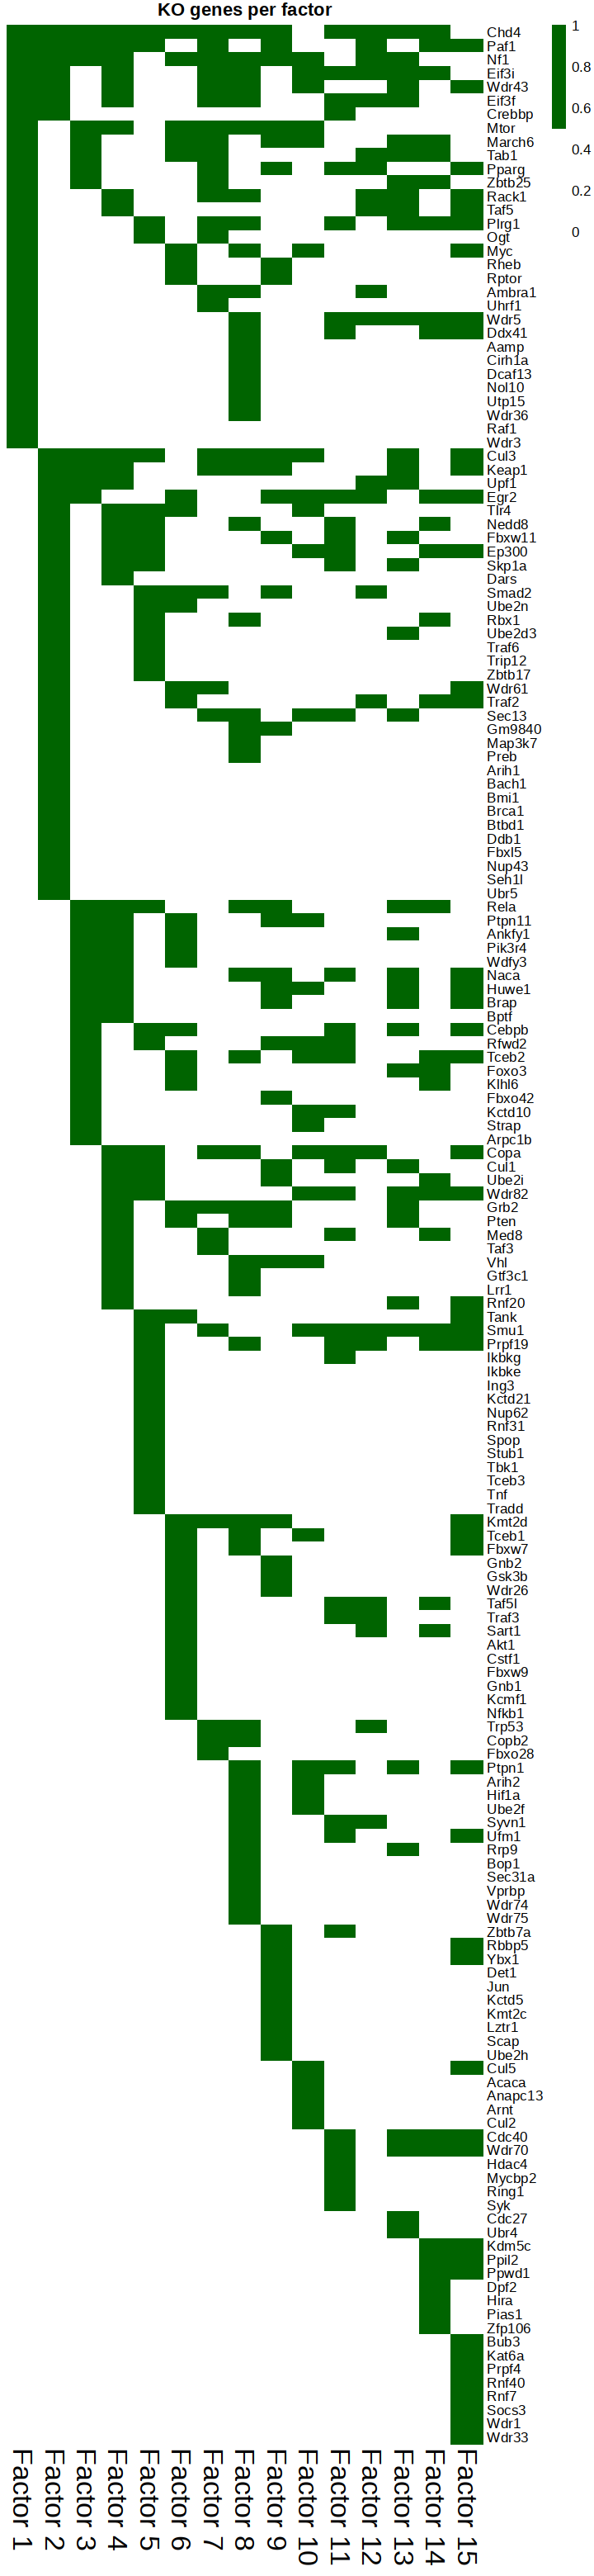

In [7]:
options(repr.plot.width = 6, repr.plot.height = 26)

pheatmap(KOFactorMatrix,
         border_color = "black",
         color = c("white", "darkgreen"),
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         main = "KO genes per factor",
         fontsize_col = 20,
         treeheight_col = 0,
         treeheight_row = 0)

## Figure S4B — outlier genes per factor

In [8]:
icaGenes <- sort(unique(unlist(myICAFactors_genes)))
GenesFactorMatrix <- data.frame(matrix(0, nrow = N_FACTORS, ncol = length(icaGenes)),
                                row.names = paste0("Factor ", 1:N_FACTORS))
colnames(GenesFactorMatrix) <- icaGenes

geneFactorNames <- factorLabel(colnames(myICAFactors_genes))
for (i in seq_along(geneFactorNames)) {
    facGenes <- myICAFactors_genes[, i]
    GenesFactorMatrix[geneFactorNames[i], facGenes[facGenes != " "]] <- 1
}
GenesFactorMatrix <- t(sortByFactors(t(GenesFactorMatrix)))

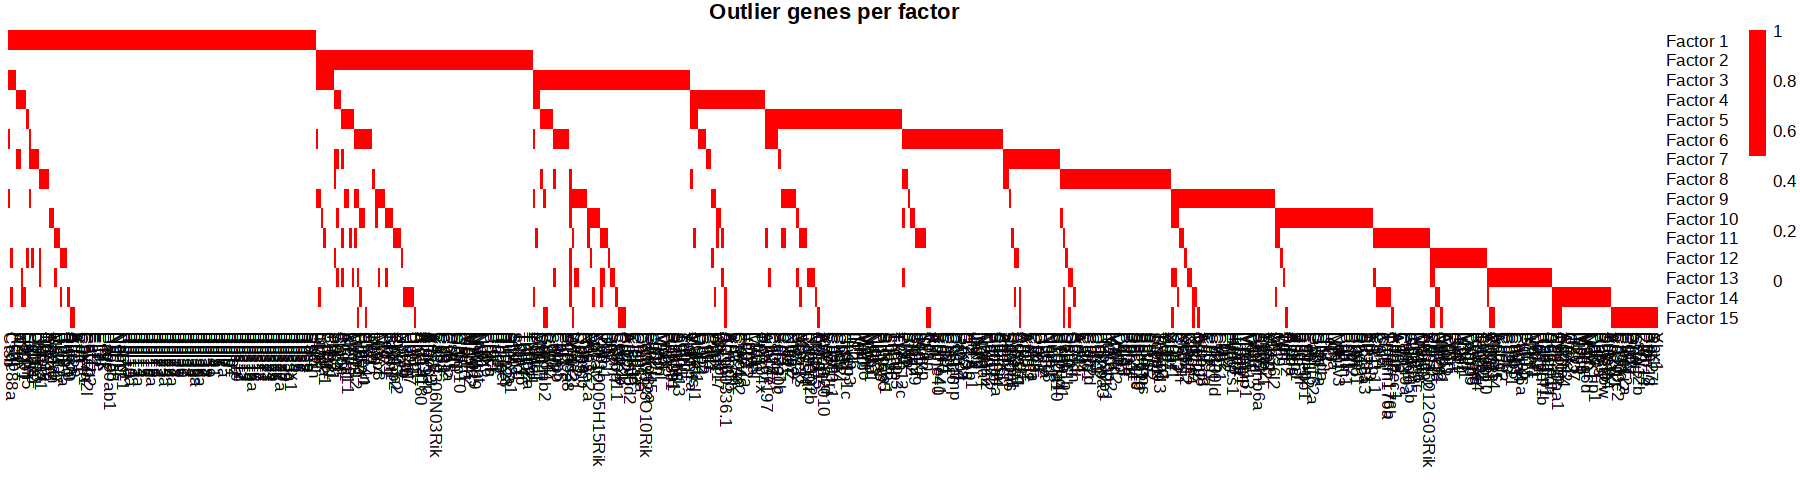

In [9]:
options(repr.plot.width = 15, repr.plot.height = 4)

xx <- pheatmap(GenesFactorMatrix,
               border_color = "black",
               color = c("white", "red"),
               cluster_cols = FALSE,
               cluster_rows = FALSE,
               main = "Outlier genes per factor",
               fontsize_col = 10,
               treeheight_col = 0,
               treeheight_row = 0)

#save_pheatmap_pdf(xx, "figures/Figure_S4B.pdf", width=15, height=4)

## Figures S5G and S5H — how much the factors overlap

Two Jaccard matrices over the fifteen factors: one on the genes they affect,
one on the knockouts they involve. S5H reuses the row and column order that
S5G's clustering produced, so the two are read against each other.

In [10]:
jaccardMatrix <- function(sets) {
    m <- outer(sets, sets, Vectorize(jaccardSets))
    diag(m) <- NA
    data.frame(m, row.names = names(sets), check.names = FALSE)
}

guideSets <- setNames(lapply(colnames(KOFactorMatrix),
                             function(f) rownames(KOFactorMatrix)[KOFactorMatrix[, f] == 1]),
                      colnames(KOFactorMatrix))
geneSets  <- setNames(lapply(rownames(GenesFactorMatrix),
                             function(f) colnames(GenesFactorMatrix)[GenesFactorMatrix[f, ] == 1]),
                      rownames(GenesFactorMatrix))

jaccGuides <- jaccardMatrix(guideSets)
jaccGenes  <- jaccardMatrix(geneSets)

### Factor overlap in the knockouts, clustered on its own

Kept from the original notebook; S5H below shows the same matrix in S5G's
order instead. The save was already commented out upstream.


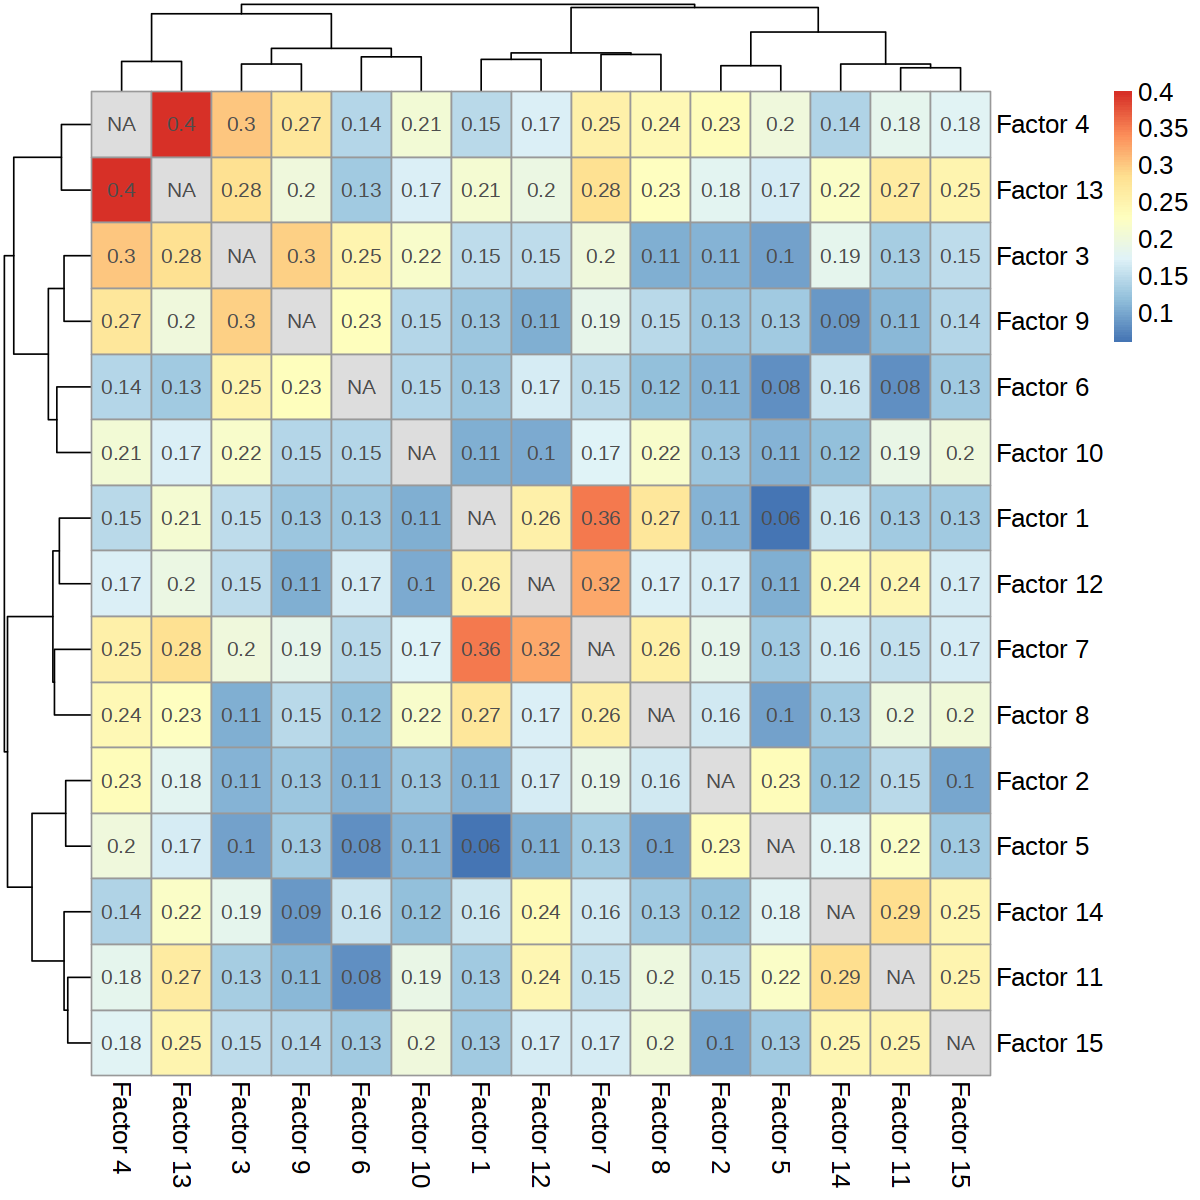

In [11]:
options(repr.plot.width = 10, repr.plot.height = 10)

xx <- pheatmap(jaccGuides,
               cluster_rows = TRUE,
               cluster_cols = TRUE,
               clustering_method = "ward.D2",
               clustering_distance_rows = "euclidean",
               clustering_distance_cols = "euclidean",
               display_numbers = round(jaccGuides, 2),
               fontsize = 15)

#save_pheatmap_pdf(xx, "figures/Figure_S4F.pdf", width=10, height=10)


agg_record_1406053153 
                    2

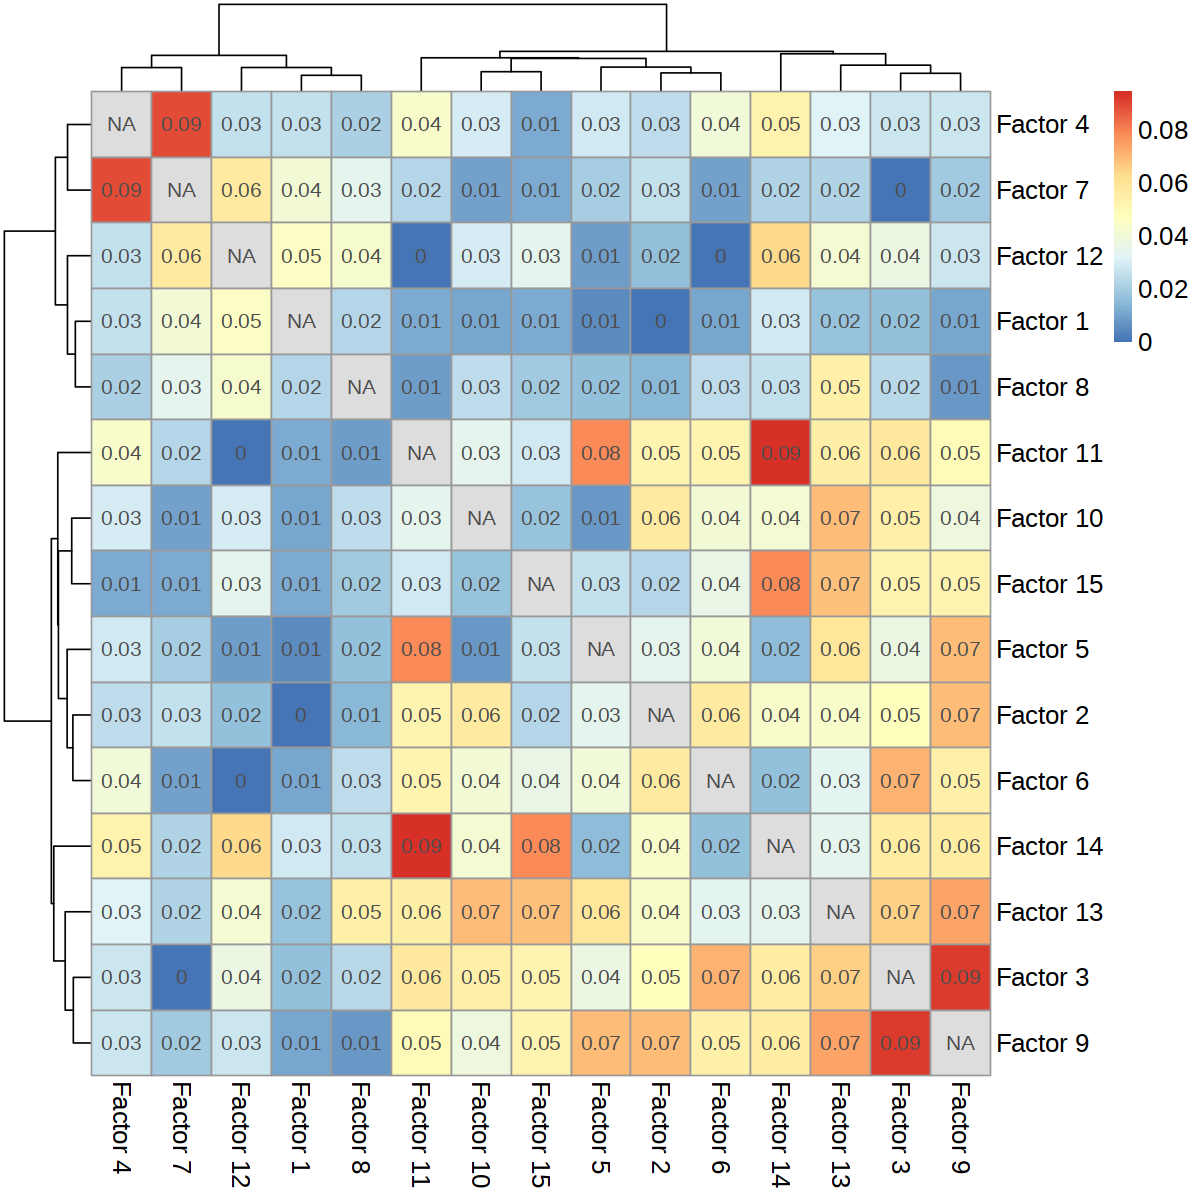

In [12]:
options(repr.plot.width = 10, repr.plot.height = 10)

xx <- pheatmap(jaccGenes,
               clustering_method = "ward.D2",
               clustering_distance_rows = "euclidean",
               clustering_distance_cols = "euclidean",
               display_numbers = round(jaccGenes, 2),
               fontsize = 15)

save_pheatmap_pdf(xx, "figures/S_5G.pdf", width = 10, height = 10)

agg_record_960850250 
                   2

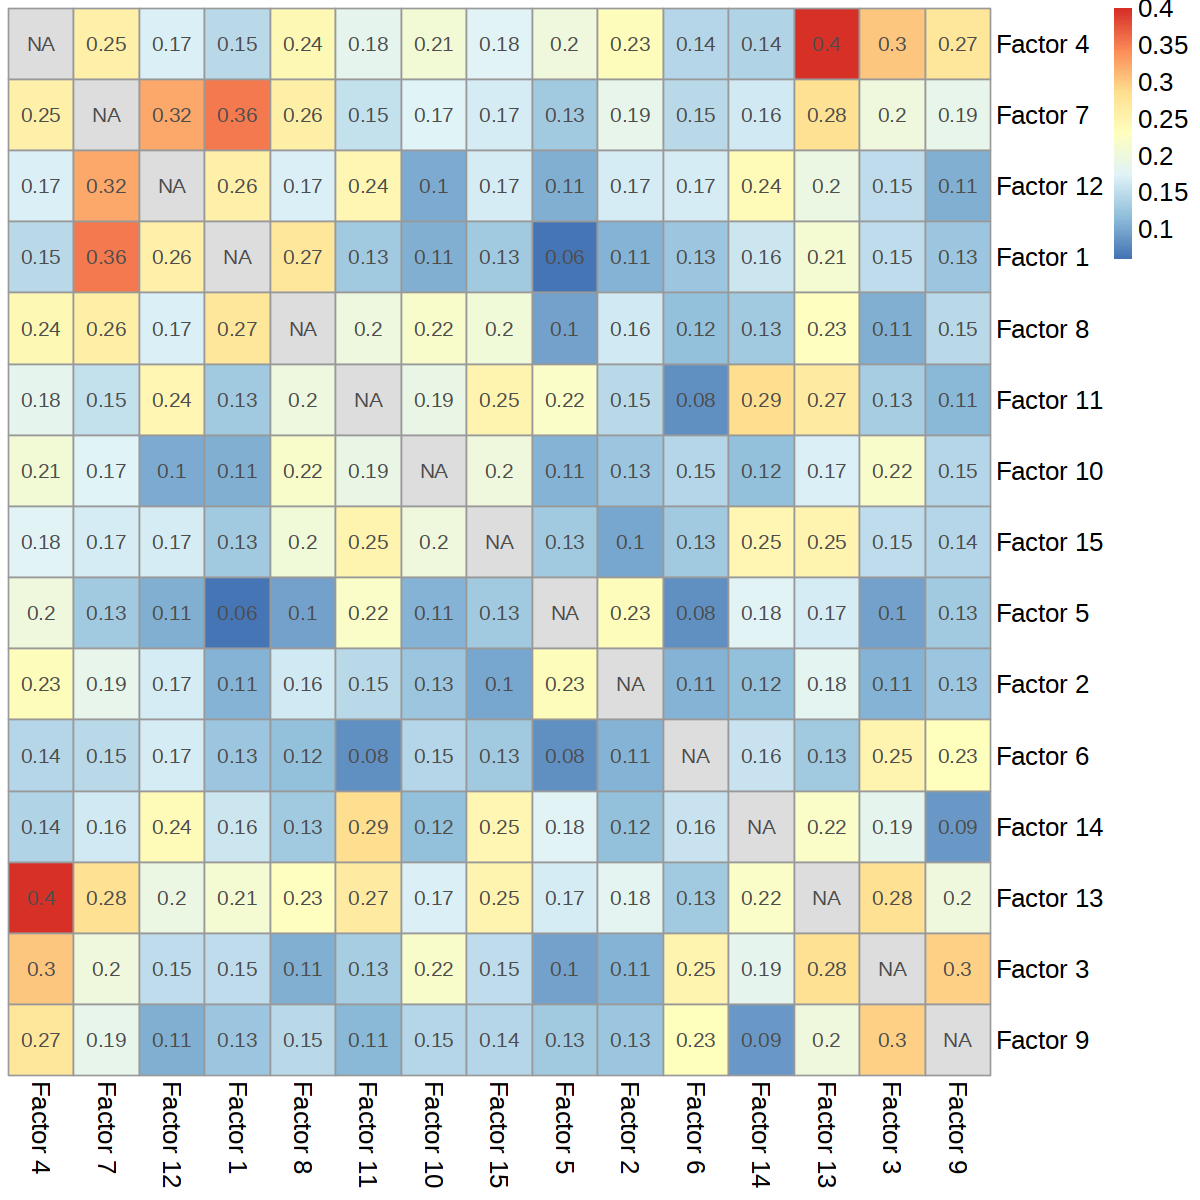

In [13]:
options(repr.plot.width = 10, repr.plot.height = 10)

rcOrder <- rownames(jaccGenes)[xx$tree_col$order]

xx <- pheatmap(jaccGuides[rcOrder, rcOrder],
               cluster_rows = FALSE,
               cluster_cols = FALSE,
               display_numbers = round(jaccGuides[rcOrder, rcOrder], 2),
               fontsize = 15)

save_pheatmap_pdf(xx, "figures/S_5H.pdf", width = 10, height = 10)